In [1]:
import json
import pandas as pd
import numpy as np
import xarray as xr

json_file = (
    "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree/loss_per_trial.json"
)

with open(json_file) as f:
    data = json.load(f)

rows = []

for trial_id, trial_data in data.items():
    params = trial_data["params"]

    # ----------------------------
    # GPP – water limited
    # ----------------------------
    for pft, loss in trial_data["gpp_loss_water"].items():
        slope_data = trial_data["gpp_slopes"].get(pft, {})
        
        rows.append({
            "trial": int(trial_id),
            "process": "GPP_water",
            "pft": pft,
            "loss": np.nan if loss == 1e6 else loss,
            "slope": slope_data.get("slope", np.nan),
            "intercept": slope_data.get("intercept", np.nan),
            **params
        })

    # ----------------------------
    # Mortality
    # ----------------------------
    for pft, loss in trial_data["mort_loss_per_pft"].items():
        slope_data = trial_data["mort_slopes"].get(pft, {})
        
        rows.append({
            "trial": int(trial_id),
            "process": "MORT",
            "pft": pft,
            "loss": np.nan if loss == 1e6 else loss,
            "slope": slope_data.get("slope", np.nan),
            "intercept": slope_data.get("intercept", np.nan),
            **params
        })

df = pd.DataFrame(rows)

# Optional: also clean slopes/intercepts if needed
df["slope"] = df["slope"].replace([1e6], np.nan)
df["intercept"] = df["intercept"].replace([1e6], np.nan)

df

,trial,process,pft,loss,slope,intercept,alpha_tropical_broadleaved_evergreen_tree,beta_tropical_broadleaved_evergreen_tree,alpha_tropical_broadleaved_raingreen_tree,beta_tropical_broadleaved_raingreen_tree,...,alpha_temperate_broadleaved_evergreen_tree,beta_temperate_broadleaved_evergreen_tree,alpha_temperate_broadleaved_summergreen_tree,beta_temperate_broadleaved_summergreen_tree,alpha_boreal_needleleaved_evergreen_tree,beta_boreal_needleleaved_evergreen_tree,alpha_boreal_broadleaved_summergreen_tree,beta_boreal_broadleaved_summergreen_tree,alpha_boreal_needleleaved_summergreen_tree,beta_boreal_needleleaved_summergreen_tree
0,0,GPP_water,tropical broadleaved evergreen tree,0.258830,-0.123975,-0.027819,0.437728,12.087330,0.402300,9.094493,...,0.071102,11.372351,0.340467,1.332393,0.877777,17.681340,0.494820,23.440023,0.971158,16.597662
1,0,GPP_water,tropical broadleaved raingreen tree,0.329875,-0.216464,-0.049463,0.437728,12.087330,0.402300,9.094493,...,0.071102,11.372351,0.340467,1.332393,0.877777,17.681340,0.494820,23.440023,0.971158,16.597662
2,0,GPP_water,temperate needleleaved evergreen tree,0.059742,0.180737,0.041423,0.437728,12.087330,0.402300,9.094493,...,0.071102,11.372351,0.340467,1.332393,0.877777,17.681340,0.494820,23.440023,0.971158,16.597662
3,0,GPP_water,temperate broadleaved evergreen tree,0.083429,0.241536,0.135119,0.437728,12.087330,0.402300,9.094493,...,0.071102,11.372351,0.340467,1.332393,0.877777,17.681340,0.494820,23.440023,0.971158,16.597662
4,0,GPP_water,temperate broadleaved summergreen tree,NaN,NaN,NaN,0.437728,12.087330,0.402300,9.094493,...,0.071102,11.372351,0.340467,1.332393,0.877777,17.681340,0.494820,23.440023,0.971158,16.597662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,99,MORT,temperate broadleaved evergreen tree,1.842827,-0.089899,0.076544,0.137451,21.857904,0.383396,23.626311,...,0.580271,16.461272,0.888152,19.148145,0.540764,5.731988,0.882362,20.601637,0.927559,14.534721
1596,99,MORT,temperate broadleaved summergreen tree,NaN,NaN,NaN,0.137451,21.857904,0.383396,23.626311,...,0.580271,16.461272,0.888152,19.148145,0.540764,5.731988,0.882362,20.601637,0.927559,14.534721
1597,99,MORT,boreal needleleaved evergreen tree,NaN,NaN,NaN,0.137451,21.857904,0.383396,23.626311,...,0.580271,16.461272,0.888152,19.148145,0.540764,5.731988,0.882362,20.601637,0.927559,14.534721
1598,99,MORT,boreal broadleaved summergreen tree,NaN,NaN,NaN,0.137451,21.857904,0.383396,23.626311,...,0.580271,16.461272,0.888152,19.148145,0.540764,5.731988,0.882362,20.601637,0.927559,14.534721


## Definitions

In [2]:
def pareto_table_for_pft(df, pft_name):
    """
    Return a DataFrame with Pareto-optimal trials for one PFT.
    Assumes df already contains only ONE GPP type (water OR energy) + MORT.
    """
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    # Identify GPP column (GPP_water or GPP_energy)
    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- Add parameters
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    params = (
        sub.drop_duplicates("trial")
           .set_index("trial")
           [[alpha_col, beta_col]]
           .reset_index()
    )

    wide = wide.merge(params, on="trial", how="left")

    # ---- Pareto mask
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Keep only Pareto-optimal
    best = wide[wide["pareto"]].copy()

    # ---- Sort nicely (optional)
    best = best.sort_values([gpp_col, "MORT"])

    # ---- Reorder columns for readability
    best = best[["trial", gpp_col, "MORT", alpha_col, beta_col, "slope", "intercept"]]

    return best


def pareto_mask(points):
    """
    Returns a boolean array marking Pareto-optimal points.
    """
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True
    return is_pareto

def interactive_pareto_for_pft(df, pft_name):
    # ---- Filter PFT
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        print(f"  ⏭️  Skipping {pft_name}: no data")
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        print(f"  ⏭️  Skipping {pft_name}: no valid pairs")
        return None

    # ---- Add parameters
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col = f"beta_{pft_key}"

    params = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    # Flatten column names
    params.columns = [
        f"{proc.lower()}_{var}" for var, proc in params.columns
    ]

    params = params.reset_index()

    wide = wide.merge(params, on="trial", how="left")

    # ---- Pareto front
    points = wide[[c for c in wide.columns if c.startswith("GPP") or c=="MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Interactive plot
    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    fig = px.scatter(
        wide,
        x=gpp_col,
        y="MORT",
        color="pareto",
        color_discrete_map={False: "lightgray", True: "red"},
        hover_data={
            "trial": True,
            gpp_col: ":.3f",
            "MORT": ":.3f",
            alpha_col: ":.3f",
            beta_col: ":.3f",
            "slope": ":.3f",
            "intercept": ":.3f",
            "pareto": False
        },
        title=f"Pareto front – {pft_name} ({gpp_col})",
    )

    fig.update_traces(marker=dict(size=8))
    fig.update_layout(legend_title_text="Pareto-optimal")
    fig.update_layout(
        legend_title_text="Pareto-optimal",
        width=950,   # width in pixels
        height=850,  # height in pixels
        yaxis=dict(range=[-0.01, 0.7]),
        xaxis=dict(range=[-0.01, 0.7])  # force equal scale for x and y
    )
    fig.show()

    return wide




In [3]:
import numpy as np
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Pareto mask
# --------------------------------------------------
def pareto_mask(points):
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True
    return is_pareto


# --------------------------------------------------
# Pareto table
# --------------------------------------------------
def pareto_table_for_pft(df, pft_name):
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- parameter names
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    # ---- alpha/beta
    params_ab = (
        sub.drop_duplicates("trial")
           .set_index("trial")[[alpha_col, beta_col]]
           .reset_index()
    )

    # ---- slopes/intercepts (per process)
    params_slopes = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    params_slopes.columns = [
        f"{proc.lower()}_{var}" for var, proc in params_slopes.columns
    ]

    params_slopes = params_slopes.reset_index()

    # ---- merge all
    wide = wide.merge(params_ab, on="trial", how="left")
    wide = wide.merge(params_slopes, on="trial", how="left")

    # ---- Pareto
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    best = wide[wide["pareto"]].copy()
    best = best.sort_values([gpp_col, "MORT"])

    return best


# --------------------------------------------------
# Knee point
# --------------------------------------------------
def select_knee_point(best, gpp_col="GPP_water", mort_col="MORT"):
    pts = best[[gpp_col, mort_col]].values

    distances = np.sqrt(pts[:, 0]**2 + pts[:, 1]**2)

    idx = np.argmin(distances)
    return best.iloc[idx]


# --------------------------------------------------
# Interactive plot
# --------------------------------------------------
def interactive_pareto_for_pft(df, pft_name):

    sub = df[df["pft"] == pft_name]

    if sub.empty:
        print(f"⏭️ Skipping {pft_name}: no data")
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        print(f"⏭️ Skipping {pft_name}: no valid pairs")
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- parameter names
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    # ---- alpha/beta
    params_ab = (
        sub.drop_duplicates("trial")
           .set_index("trial")[[alpha_col, beta_col]]
           .reset_index()
    )

    # ---- slopes/intercepts
    params_slopes = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    params_slopes.columns = [
        f"{proc.lower()}_{var}" for var, proc in params_slopes.columns
    ]

    params_slopes = params_slopes.reset_index()

    # ---- merge
    wide = wide.merge(params_ab, on="trial", how="left")
    wide = wide.merge(params_slopes, on="trial", how="left")

    # ---- Pareto
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Knee point
    best = wide[wide["pareto"]].copy()
    if best.empty:
        print(f"⏭️ No Pareto points for {pft_name}")
        return None

    knee = select_knee_point(best, gpp_col=gpp_col)

    # mark knee
    wide["knee"] = False
    wide.loc[wide["trial"] == knee["trial"], "knee"] = True

    # ---- color logic
    def color_label(row):
        if row["knee"]:
            return "knee"
        elif row["pareto"]:
            return "pareto"
        else:
            return "other"

    wide["category"] = wide.apply(color_label, axis=1)

    color_map = {
        "other": "lightgray",
        "pareto": "red",
        "knee": "blue"
    }

    # ---- hover (robust)
    hover_dict = {
        "trial": True,
        gpp_col: ":.3f",
        "MORT": ":.3f",
    }

    for col in wide.columns:
        if col not in ["trial", gpp_col, "MORT", "category", "pareto", "knee"]:
            hover_dict[col] = ":.3f"

    # ---- plot
    fig = px.scatter(
        wide,
        x=gpp_col,
        y="MORT",
        color="category",
        color_discrete_map=color_map,
        hover_data=hover_dict,
        title=f"Pareto front – {pft_name}"
    )

    fig.update_traces(marker=dict(size=9))
    fig.update_layout(
        width=950,
        height=850,
        xaxis=dict(range=[-0.01, 0.7]),
        yaxis=dict(range=[-0.01, 0.7]),
        legend_title="Point type"
    )

    fig.show()
    
    # ---- Print Pareto table
    best = pareto_table_for_pft(df, pft_name)

    if best is not None and not best.empty:
        gpp_col = [c for c in best.columns if c.startswith("GPP")][0]

        print("\n" + "="*60)
        print(f"Pareto-optimal trials (water-limited) – {pft_name}")
        print("="*60)

        # Select only relevant columns
        cols = ["trial", gpp_col, "MORT"]

        # Add alpha/beta
        pft_key = pft_name.replace(" ", "_")
        alpha_col = f"alpha_{pft_key}"
        beta_col  = f"beta_{pft_key}"

        cols += [alpha_col, beta_col]

        print(best[cols].to_string(index=False))

        return wide, int(knee["trial"]), best

In [4]:
for pft in df["pft"].unique():
    interactive_pareto_for_pft(df, pft)


Pareto-optimal trials (water-limited) – tropical broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_evergreen_tree  beta_tropical_broadleaved_evergreen_tree
    46   0.051836 0.320274                                   0.013497                                  3.055370
    33   0.071491 0.278389                                   0.017430                                 16.921387
    76   0.073543 0.277431                                   0.017430                                 20.011179
    10   0.085996 0.264026                                   0.021942                                 15.637667
     3   0.196146 0.182195                                   0.078543                                 23.926931
    68   0.196309 0.181977                                   0.078543                                 24.522116
    66   0.213906 0.155067                                   0.113070                                 21.528777



Pareto-optimal trials (water-limited) – tropical broadleaved raingreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_raingreen_tree  beta_tropical_broadleaved_raingreen_tree
    46   0.061491 0.356265                                   0.085588                                  6.525343
    68   0.192023 0.222690                                   0.333952                                 10.047270
     3   0.192293 0.221977                                   0.333952                                 10.047270



Pareto-optimal trials (water-limited) – temperate needleleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_needleleaved_evergreen_tree  beta_temperate_needleleaved_evergreen_tree
    18   0.007266 0.844117                                     0.295681                                    8.377819
    67   0.013695 0.794467                                     0.297046                                    6.730302
    74   0.014235 0.647280                                     0.365005                                    5.189501
     5   0.048913 0.193884                                     0.149078                                    2.766237
     0   0.059742 0.154953                                     0.137467                                   16.446453
    43   0.119131 0.134971                                     0.147778                                    1.925742
    42   0.269271 0.085345                                     0.182270                                    3.


Pareto-optimal trials (water-limited) – temperate broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_broadleaved_evergreen_tree  beta_temperate_broadleaved_evergreen_tree
    10   0.024740 1.924123                                    0.884890                                   0.665707
    47   0.047366 1.125708                                    0.242378                                  16.504654
    60   0.054871 1.084861                                    0.264727                                  19.842650
    30   0.058400 0.873808                                    0.191600                                  17.955877
    49   0.060515 0.526923                                    0.405771                                   0.179267
    93   0.071754 0.199853                                    0.112405                                   3.214386
⏭️ Skipping temperate broadleaved summergreen tree: no valid pairs
⏭️ Skipping boreal needleleaved evergreen tree: no valid 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

locations = [
    "patch_1", "patch_2", "patch_3", "patch_4", "patch_5",
    "patch_6", "patch_7", "patch_8", "patch_9", "patch_10"
]
OUTPUT_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree"

def standardized_anomalies(data):
    data_ref = data.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m)/s if s!=0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

obs_spei = xr.open_dataset(
    "/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc"
)["SPEI"]

S_obs_mort = -0.46
intercept_mort = -1.96

S_obs_gpp_water = {0:0.14,1:0.12,2:0.12,3:0.17,4:0.18,5:0.08,6:0.08,7:0.10}
intercept_gpp = {0:0.02,1:0.03,2:0.02,3:0.04,4:0.04,5:0.01,6:0.00,7:0.01}

START_YEAR = 2000
END_YEAR   = 2019

In [6]:
import numpy as np
import os
import xarray as xr

def get_knee_per_pft(df, pft_name):

    sub = df[df["pft"] == pft_name]
    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    points = wide[[gpp_col, "MORT"]].values

    # Pareto mask
    is_pareto = np.ones(len(points), dtype=bool)

    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True

    pareto = wide[is_pareto]

    if pareto.empty:
        return None

    # knee (closest to origin)
    pts = pareto[[gpp_col, "MORT"]].values
    idx = np.argmin(np.sqrt(pts[:, 0]**2 + pts[:, 1]**2))
    knee = pareto.iloc[idx]

    trial = int(knee["trial"])

    # parameter row
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    row = sub[sub["trial"] == trial].iloc[0]

    # slopes/intercepts
    slopes = sub[sub["trial"] == trial].set_index("process")["slope"].to_dict()
    intercepts = sub[sub["trial"] == trial].set_index("process")["intercept"].to_dict()

    return {
        "pft": pft_name,
        "trial": trial,
        "GPP_loss": float(knee[gpp_col]),
        "MORT_loss": float(knee["MORT"]),
        "alpha": float(row[alpha_col]),
        "beta": float(row[beta_col]),
        "slopes": slopes,
        "intercepts": intercepts
    }

In [7]:
def build_knee_cache(df):

    cache = {}

    for pft in df["pft"].unique():

        out = get_knee_per_pft(df, pft)

        if out is None:
            continue

        cache[pft] = out

    return cache

In [8]:
import matplotlib.pyplot as plt

def plot_spei_from_cache(
    knee_cache,
    OUTPUT_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp,
    standardized_anomalies
):

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    spei_local = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))

    for i, (pft, info) in enumerate(list(knee_cache.items())[:8]):

        ax = axes[i]

        trial = info["trial"]
        trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

        all_spei = []
        all_gpp = []

        for loc in locations:

            path = os.path.join(trial_dir, loc, "output")

            gpp = xr.open_dataset(os.path.join(path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc["pft"] = fpc.pft - 1

            gpp_std = standardized_anomalies(gpp / fpc.where(fpc > 1e-5))

            spei_loc = spei_local.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

            spei_flat = spei_loc.values.flatten()
            gpp_flat = gpp_std.isel(pft=0).values.flatten()

            mask = np.isfinite(spei_flat) & np.isfinite(gpp_flat)

            all_spei.append(spei_flat[mask])
            all_gpp.append(gpp_flat[mask])

        all_spei = np.concatenate(all_spei)
        all_gpp = np.concatenate(all_gpp)

        ax.scatter(all_spei, all_gpp, s=5, alpha=0.2)

        x = np.linspace(np.nanmin(all_spei), np.nanmax(all_spei), 100)

        # model line
        S_model = info["slopes"]["GPP_water"]
        b_model = info["intercepts"]["GPP_water"]
        ax.plot(x, S_model * x + b_model, color="red")

        # observed line
        ax.plot(x, S_obs_gpp_water[i] * x + intercept_gpp[i], color="black")

        ax.set_title(
            f"{pft}\ntrial {trial}\n"
            f"GPP {info['GPP_loss']:.3f} | MORT {info['MORT_loss']:.3f}"
        )

    plt.tight_layout()
    plt.show()

In [9]:
knee_cache = build_knee_cache(df)
knee_cache

{'tropical broadleaved evergreen tree': {'pft': 'tropical broadleaved evergreen tree',
  'trial': 66,
  'GPP_loss': 0.21390585525536673,
  'MORT_loss': 0.15506742669434462,
  'alpha': 0.11307042924757664,
  'beta': 21.528776665269717,
  'slopes': {'GPP_water': -0.0775828822832365, 'MORT': -0.2857548884211683},
  'intercepts': {'GPP_water': -0.018303694344440624,
   'MORT': -1.885975967121254}},
 'tropical broadleaved raingreen tree': {'pft': 'tropical broadleaved raingreen tree',
  'trial': 3,
  'GPP_loss': 0.1922934767201172,
  'MORT_loss': 0.22197732435985612,
  'alpha': 0.33395230446496454,
  'beta': 10.047269603227067,
  'slopes': {'GPP_water': -0.07664491723368418, 'MORT': -0.3879903237948581},
  'intercepts': {'GPP_water': -0.01979397363306066,
   'MORT': -1.7300506339136428}},
 'temperate needleleaved evergreen tree': {'pft': 'temperate needleleaved evergreen tree',
  'trial': 0,
  'GPP_loss': 0.05974225809255172,
  'MORT_loss': 0.15495260653188514,
  'alpha': 0.1374670927703738

In [10]:
# plot_spei_from_cache(
#     knee_cache=knee_cache,
#     OUTPUT_DIR="/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree",
#     locations=locations,
#     obs_spei=obs_spei,
#     START_YEAR=2000,
#     END_YEAR=2019,
#     S_obs_gpp_water=S_obs_gpp_water,
#     intercept_gpp=intercept_gpp,
#     standardized_anomalies=standardized_anomalies
# )

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os


def plot_gpp_mort_separated(
    knee_cache,
    OUTPUT_DIR,
    BASELINE_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp,
    S_obs_mort,
    intercept_mort,
    standardized_anomalies
):

    def fmt_line(name, slope, intercept):
        return f"{name}: y = {slope:.2f} x + {intercept:.2f}"

    fig, axes = plt.subplots(8, 2, figsize=(14, 20), sharex=True)

    spei_local = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    spei_monthly = spei_local

    for i, (pft, info) in enumerate(list(knee_cache.items())[:8]):

        trial = info["trial"]
        trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

        # containers (trial)
        gpp_spei_all, gpp_all = [], []
        mort_spei_all, mort_all = [], []

        # containers (baseline)
        gpp_spei_base, gpp_base = [], []
        mort_spei_base, mort_base = [], []

        spei_year = spei_monthly.resample(time="YS").mean()

        # -------------------------
        # loop locations
        # -------------------------
        for loc in locations:

            # ===== TRIAL =====
            path = os.path.join(trial_dir, loc, "output")

            gpp = xr.open_dataset(os.path.join(path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            mort = xr.open_dataset(os.path.join(path, "pft_mort.nc")).mortality.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc["pft"] = fpc.pft - 1

            # GPP
            gpp_std = standardized_anomalies(gpp / fpc.where(fpc > 1e-5))
            spei_loc = spei_monthly.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

            gpp_flat = gpp_std.isel(pft=0).values.flatten()
            spei_flat = spei_loc.values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)
            gpp_spei_all.append(spei_flat[mask])
            gpp_all.append(gpp_flat[mask])

            # MORT
            mort_ann = mort.resample(time="YS").sum()
            mort_ann = np.log10(mort_ann)

            spei_ann = spei_year.sel(lat=mort.lat, lon=mort.lon, method="nearest")

            mort_flat = mort_ann.isel(pft=0).values.flatten()
            spei_m_flat = spei_ann.values.flatten()

            mask_m = np.isfinite(mort_flat) & np.isfinite(spei_m_flat)
            mort_spei_all.append(spei_m_flat[mask_m])
            mort_all.append(mort_flat[mask_m])

            # ===== BASELINE =====
            baseline_path = os.path.join(BASELINE_DIR, loc, "output")

            gpp_b = xr.open_dataset(os.path.join(baseline_path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            mort_b = xr.open_dataset(os.path.join(baseline_path, "pft_mort.nc")).mortality.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc_b = xr.open_dataset(os.path.join(baseline_path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc_b["pft"] = fpc_b.pft - 1

            # GPP baseline
            gpp_std_b = standardized_anomalies(gpp_b / fpc_b.where(fpc_b > 1e-5))
            spei_loc_b = spei_monthly.sel(lat=gpp_b.lat, lon=gpp_b.lon, method="nearest")

            gpp_flat_b = gpp_std_b.isel(pft=0).values.flatten()
            spei_flat_b = spei_loc_b.values.flatten()

            mask_b = np.isfinite(gpp_flat_b) & np.isfinite(spei_flat_b)
            gpp_spei_base.append(spei_flat_b[mask_b])
            gpp_base.append(gpp_flat_b[mask_b])

            # MORT baseline
            mort_ann_b = mort_b.resample(time="YS").sum()
            mort_ann_b = np.log10(mort_ann_b)

            spei_ann_b = spei_year.sel(lat=mort_b.lat, lon=mort_b.lon, method="nearest")

            mort_flat_b = mort_ann_b.isel(pft=0).values.flatten()
            spei_m_flat_b = spei_ann_b.values.flatten()

            mask_mb = np.isfinite(mort_flat_b) & np.isfinite(spei_m_flat_b)
            mort_spei_base.append(spei_m_flat_b[mask_mb])
            mort_base.append(mort_flat_b[mask_mb])

        # -------------------------
        # concat
        # -------------------------
        gpp_spei_all = np.concatenate(gpp_spei_all)
        gpp_all = np.concatenate(gpp_all)

        mort_spei_all = np.concatenate(mort_spei_all)
        mort_all = np.concatenate(mort_all)

        gpp_spei_base = np.concatenate(gpp_spei_base)
        gpp_base = np.concatenate(gpp_base)

        mort_spei_base = np.concatenate(mort_spei_base)
        mort_base = np.concatenate(mort_base)

        # baseline regression
        m_base_gpp, b_base_gpp = np.polyfit(gpp_spei_base, gpp_base, 1)
        m_base_mort, b_base_mort = np.polyfit(mort_spei_base, mort_base, 1)

        # -------------------------
        # GPP panel
        # -------------------------
        ax_gpp = axes[i, 0]

        # scatter
        ax_gpp.scatter(gpp_spei_all, gpp_all, s=5, alpha=0.01, color="tab:orange", label="best trial")
        ax_gpp.scatter(gpp_spei_base, gpp_base, s=5, alpha=0.01, color="tab:blue", label="baseline")

        x = np.linspace(np.nanmin(gpp_spei_all), np.nanmax(gpp_spei_all), 100)

        # trial model (orange)
        m_trial_gpp = info["slopes"]["GPP_water"]
        b_trial_gpp = info["intercepts"]["GPP_water"]

        ax_gpp.plot(
            x, m_trial_gpp * x + b_trial_gpp,
            color="tab:orange",
            label=fmt_line("best trial", m_trial_gpp, b_trial_gpp)
        )

        # obs (gray dashed)
        m_obs_gpp = S_obs_gpp_water[i]
        b_obs_gpp = intercept_gpp[i]

        ax_gpp.plot(
            x, m_obs_gpp * x + b_obs_gpp,
            color="black", linestyle="--",
            label=fmt_line("objective", m_obs_gpp, b_obs_gpp)
        )

        # baseline fit (black dotted)
        ax_gpp.plot(
            x, m_base_gpp * x + b_base_gpp,
            color="tab:blue", 
            label=fmt_line("baseline", m_base_gpp, b_base_gpp)
        )

        ax_gpp.set_title(f"{pft}\nGPP (trial {trial})")
        ax_gpp.legend(fontsize=8)

        # -------------------------
        # MORT panel
        # -------------------------
        ax_m = axes[i, 1]

        # scatter
        ax_m.scatter(mort_spei_all, mort_all, s=5, alpha=0.01, color="tab:orange", label="best trial")
        ax_m.scatter(mort_spei_base, mort_base, s=5, alpha=0.01, color="tab:blue", label="baseline")

        x = np.linspace(np.nanmin(mort_spei_all), np.nanmax(mort_spei_all), 100)

        # trial model (orange)
        m_trial_mort = info["slopes"]["MORT"]
        b_trial_mort = info["intercepts"]["MORT"]

        ax_m.plot(
            x, m_trial_mort * x + b_trial_mort,
            color="tab:orange",
            label=fmt_line("best trial", m_trial_mort, b_trial_mort)
        )

        # obs
        ax_m.plot(
            x, S_obs_mort * x + intercept_mort,
            color="black", linestyle="--",
            label=fmt_line("objective", S_obs_mort, intercept_mort)
        )

        # baseline fit (black dotted)
        ax_m.plot(
            x, m_base_mort * x + b_base_mort,
            color="tab:blue",
            label=fmt_line("baseline", m_base_mort, b_base_mort)
        )

        ax_m.set_title(f"{pft}\nMORT (annual)")
        ax_m.legend(fontsize=8)

    # labels
    axes[0, 0].set_ylabel("GPP response")
    axes[0, 1].set_ylabel("log10(Mortality)")
    axes[-1, 0].set_xlabel("SPEI")
    axes[-1, 1].set_xlabel("SPEI")

    # legends (top row only)
    axes[0, 0].legend()
    axes[0, 1].legend()

    plt.tight_layout()
    plt.show()

/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

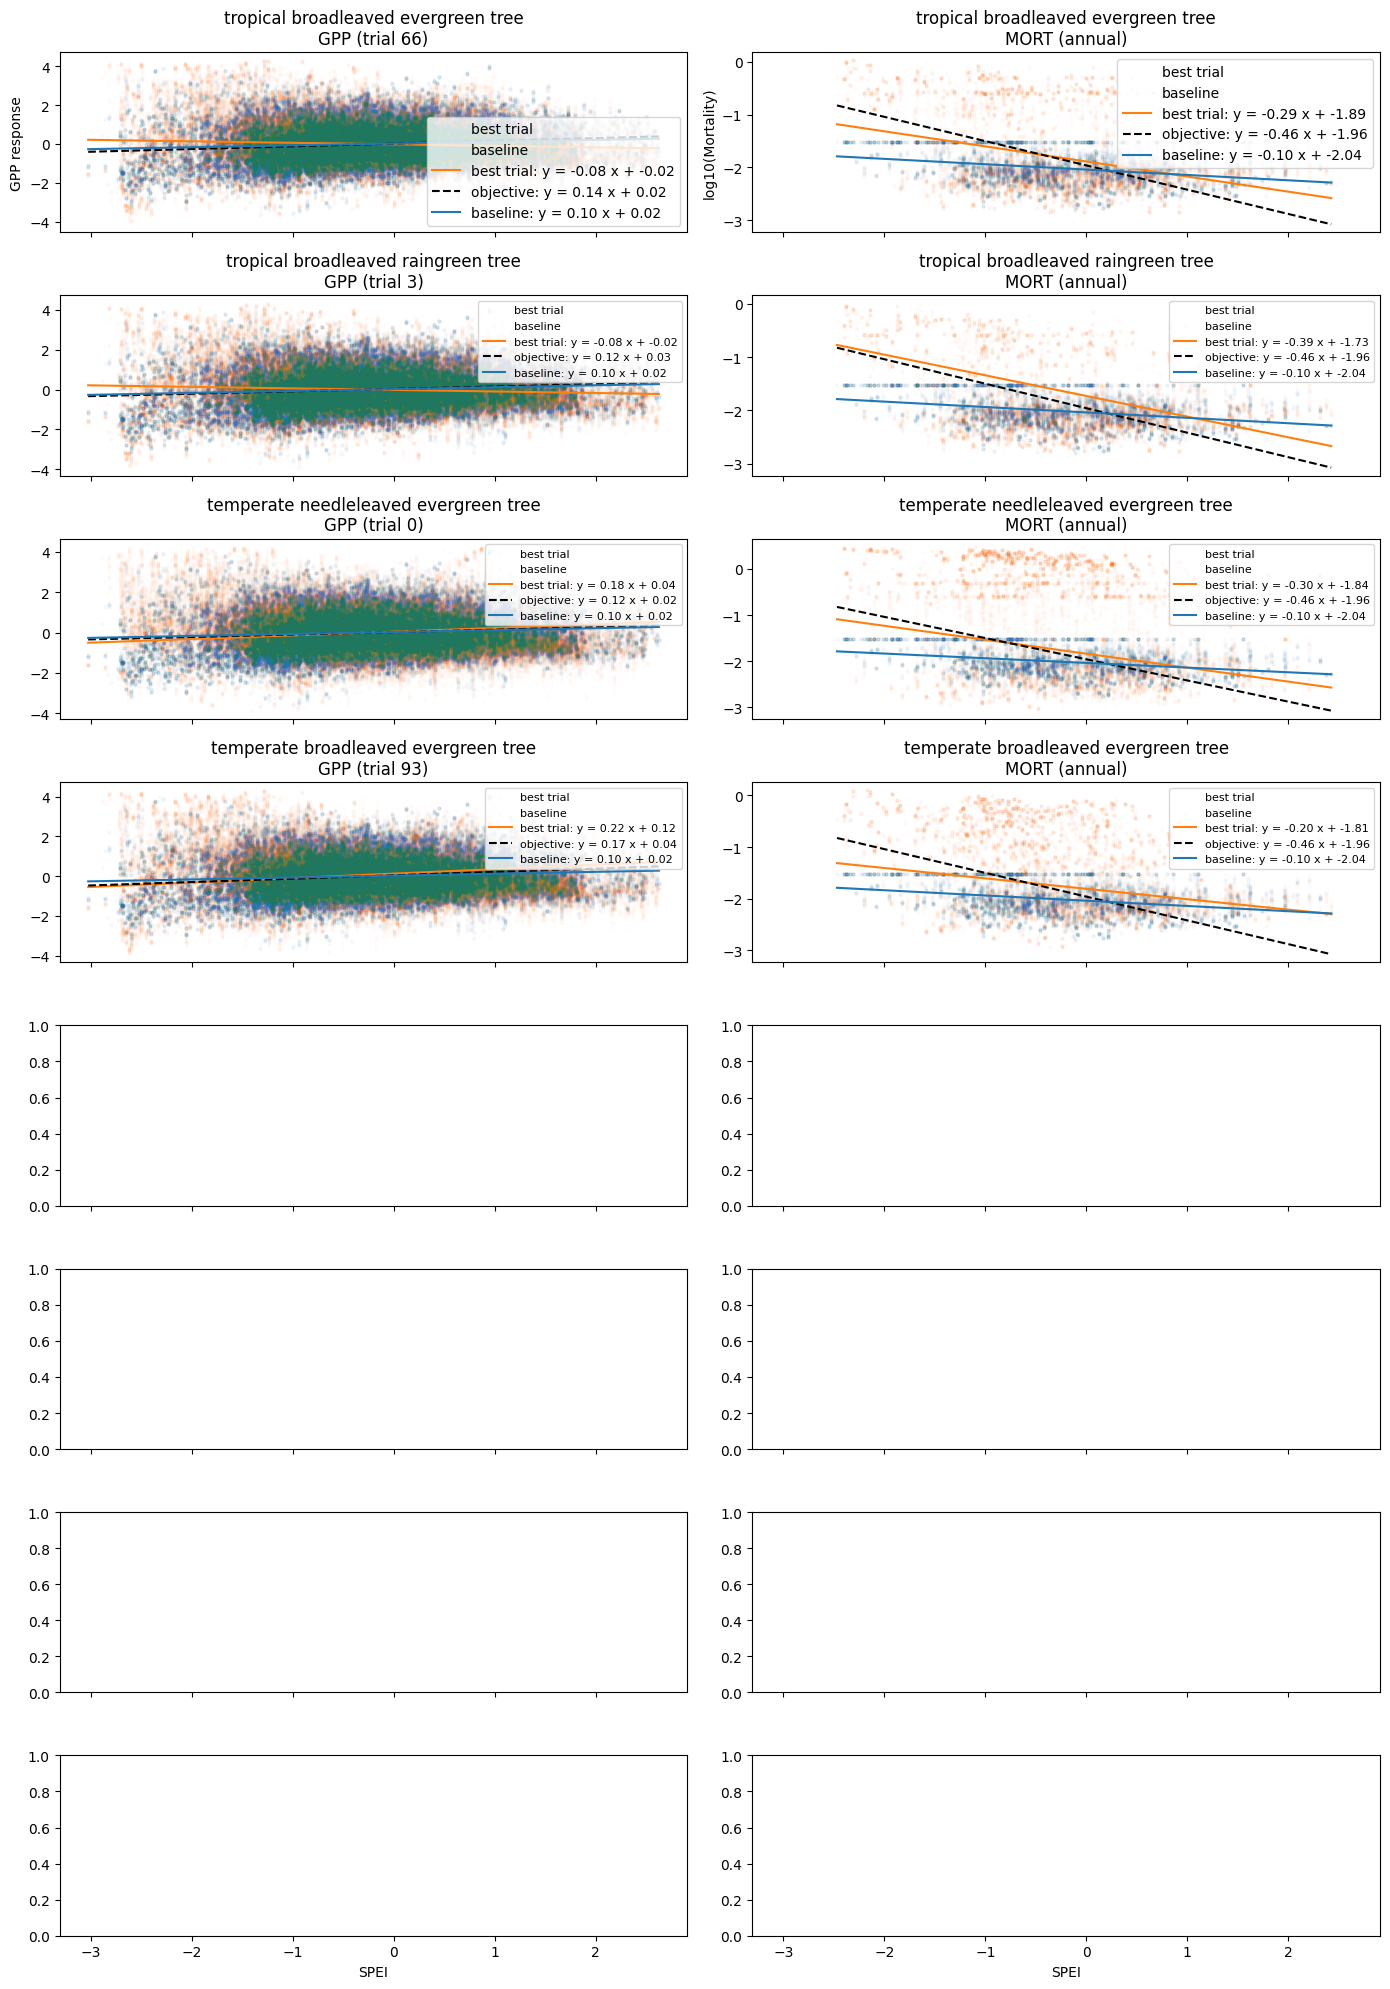

In [16]:
plot_gpp_mort_separated(
    knee_cache=knee_cache,
    OUTPUT_DIR=OUTPUT_DIR,
    BASELINE_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree/baseline_MM",
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=2000,
    END_YEAR=2019,
    S_obs_gpp_water=S_obs_gpp_water,
    intercept_gpp=intercept_gpp,
    S_obs_mort=-0.46,
    intercept_mort=-1.96,
    standardized_anomalies=standardized_anomalies
)

In [43]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


def plot_temperate_nee_timeseries(
    knee_cache,
    OUTPUT_DIR,
    BASELINE_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    standardized_anomalies,
    n_patches=10
):

    # -------------------------
    # correct PFT key from your dict
    # -------------------------
    pft_key = "temperate needleleaved evergreen tree"
    info = knee_cache[pft_key]
    trial = info["trial"]
    print(trial)
    

    trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

    sel_locs = locations[:n_patches]

    fig, axes = plt.subplots(n_patches, 1, figsize=(14, 2.5 * n_patches), sharex=True)
    if n_patches == 1:
        axes = [axes]

    spei = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    
    


    # -------------------------
    # helper correlation
    # -------------------------
    def corr(x, y):
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            return np.nan
        return np.corrcoef(x[mask], y[mask])[0, 1]

    for i, loc in enumerate(sel_locs):


        ax = axes[i]

        # =========================
        # TRIAL
        # =========================
        path = os.path.join(trial_dir, loc, "output")

        gpp = xr.open_dataset(os.path.join(path, "mgpp.nc")).GPP.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        )

        # fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(
        #     time=slice(f"{START_YEAR}", f"{END_YEAR}")
        # )
        # fpc["pft"] = fpc.pft - 1

        # gpp_std = standardized_anomalies(
        #     (gpp / fpc.where(fpc > 1e-5))
        # ).isel(pft=2)
        
        # gpp_std = standardized_anomalies(gpp)

        spei_loc = spei.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

        # =========================
        # BASELINE
        # =========================
        base_path = os.path.join(BASELINE_DIR, loc, "output")

        gpp_b = xr.open_dataset(os.path.join(base_path, "mgpp.nc")).GPP.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        )

        # fpc_b = xr.open_dataset(os.path.join(base_path, "fpc.nc")).FPC[:, 1:].sel(
        #     time=slice(f"{START_YEAR}", f"{END_YEAR}")
        # )
        # fpc_b["pft"] = fpc_b.pft - 1

        # gpp_std_b = standardized_anomalies(
        #     (gpp_b / fpc_b.where(fpc_b > 1e-5))
        # ).isel(pft=2)
        
        # gpp_std_b = standardized_anomalies(gpp_b)


        # # =========================
        # # align
        # # =========================
        # gpp_std = gpp_std.squeeze()
        # gpp_std_b = gpp_std_b.squeeze()
        # spei_loc = spei_loc.squeeze()

        # # keep only time dimension
        # gpp_std = gpp_std.dropna("time", how="all")
        # gpp_std_b = gpp_std_b.dropna("time", how="all")
        
        # -------------------------
        # collapse spatial dimensions FIRST
        # -------------------------
        gpp_std = gpp.mean(dim=["lat", "lon"]).convert_calendar("standard")
        gpp_std_b = gpp_b.mean(dim=["lat", "lon"]).convert_calendar("standard")
        spei_loc = spei_loc.mean(dim=["lat", "lon"])

        # now they are (time,) ONLY
        
        print(loc)

        # =========================
        # correlations
        # =========================
        c_trial = corr(gpp_std.values, spei_loc.values)
        c_base = corr(gpp_std_b.values, spei_loc.values)

        print(f"{loc} | trial: {c_trial:.3f} | baseline: {c_base:.3f}")

        # =========================
        # plot
        # =========================
        ax.plot(gpp_std.time, gpp_std, color="tab:orange", label="GPP std (trial)")
        ax.plot(gpp_std_b.time, gpp_std_b, color="tab:blue", label="GPP std (baseline)")
        ax.plot(spei_loc.time, spei_loc, color="black", linestyle="--", label="SPEI-12")

        ax.axhline(0, color="gray", linewidth=0.5)
        ax.set_title(f"{loc} | corr trial={c_trial:.2f}, base={c_base:.2f}")

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

0
patch_1
patch_1 | trial: -0.031 | baseline: 0.260
patch_2
patch_2 | trial: 0.046 | baseline: 0.167
patch_3
patch_3 | trial: -0.134 | baseline: 0.166
patch_4
patch_4 | trial: -0.015 | baseline: -0.041
patch_5
patch_5 | trial: 0.093 | baseline: 0.070
patch_6
patch_6 | trial: 0.140 | baseline: 0.150
patch_7
patch_7 | trial: -0.069 | baseline: 0.145
patch_8
patch_8 | trial: 0.086 | baseline: 0.154
patch_9
patch_9 | trial: -0.039 | baseline: 0.150
patch_10
patch_10 | trial: 0.130 | baseline: 0.149


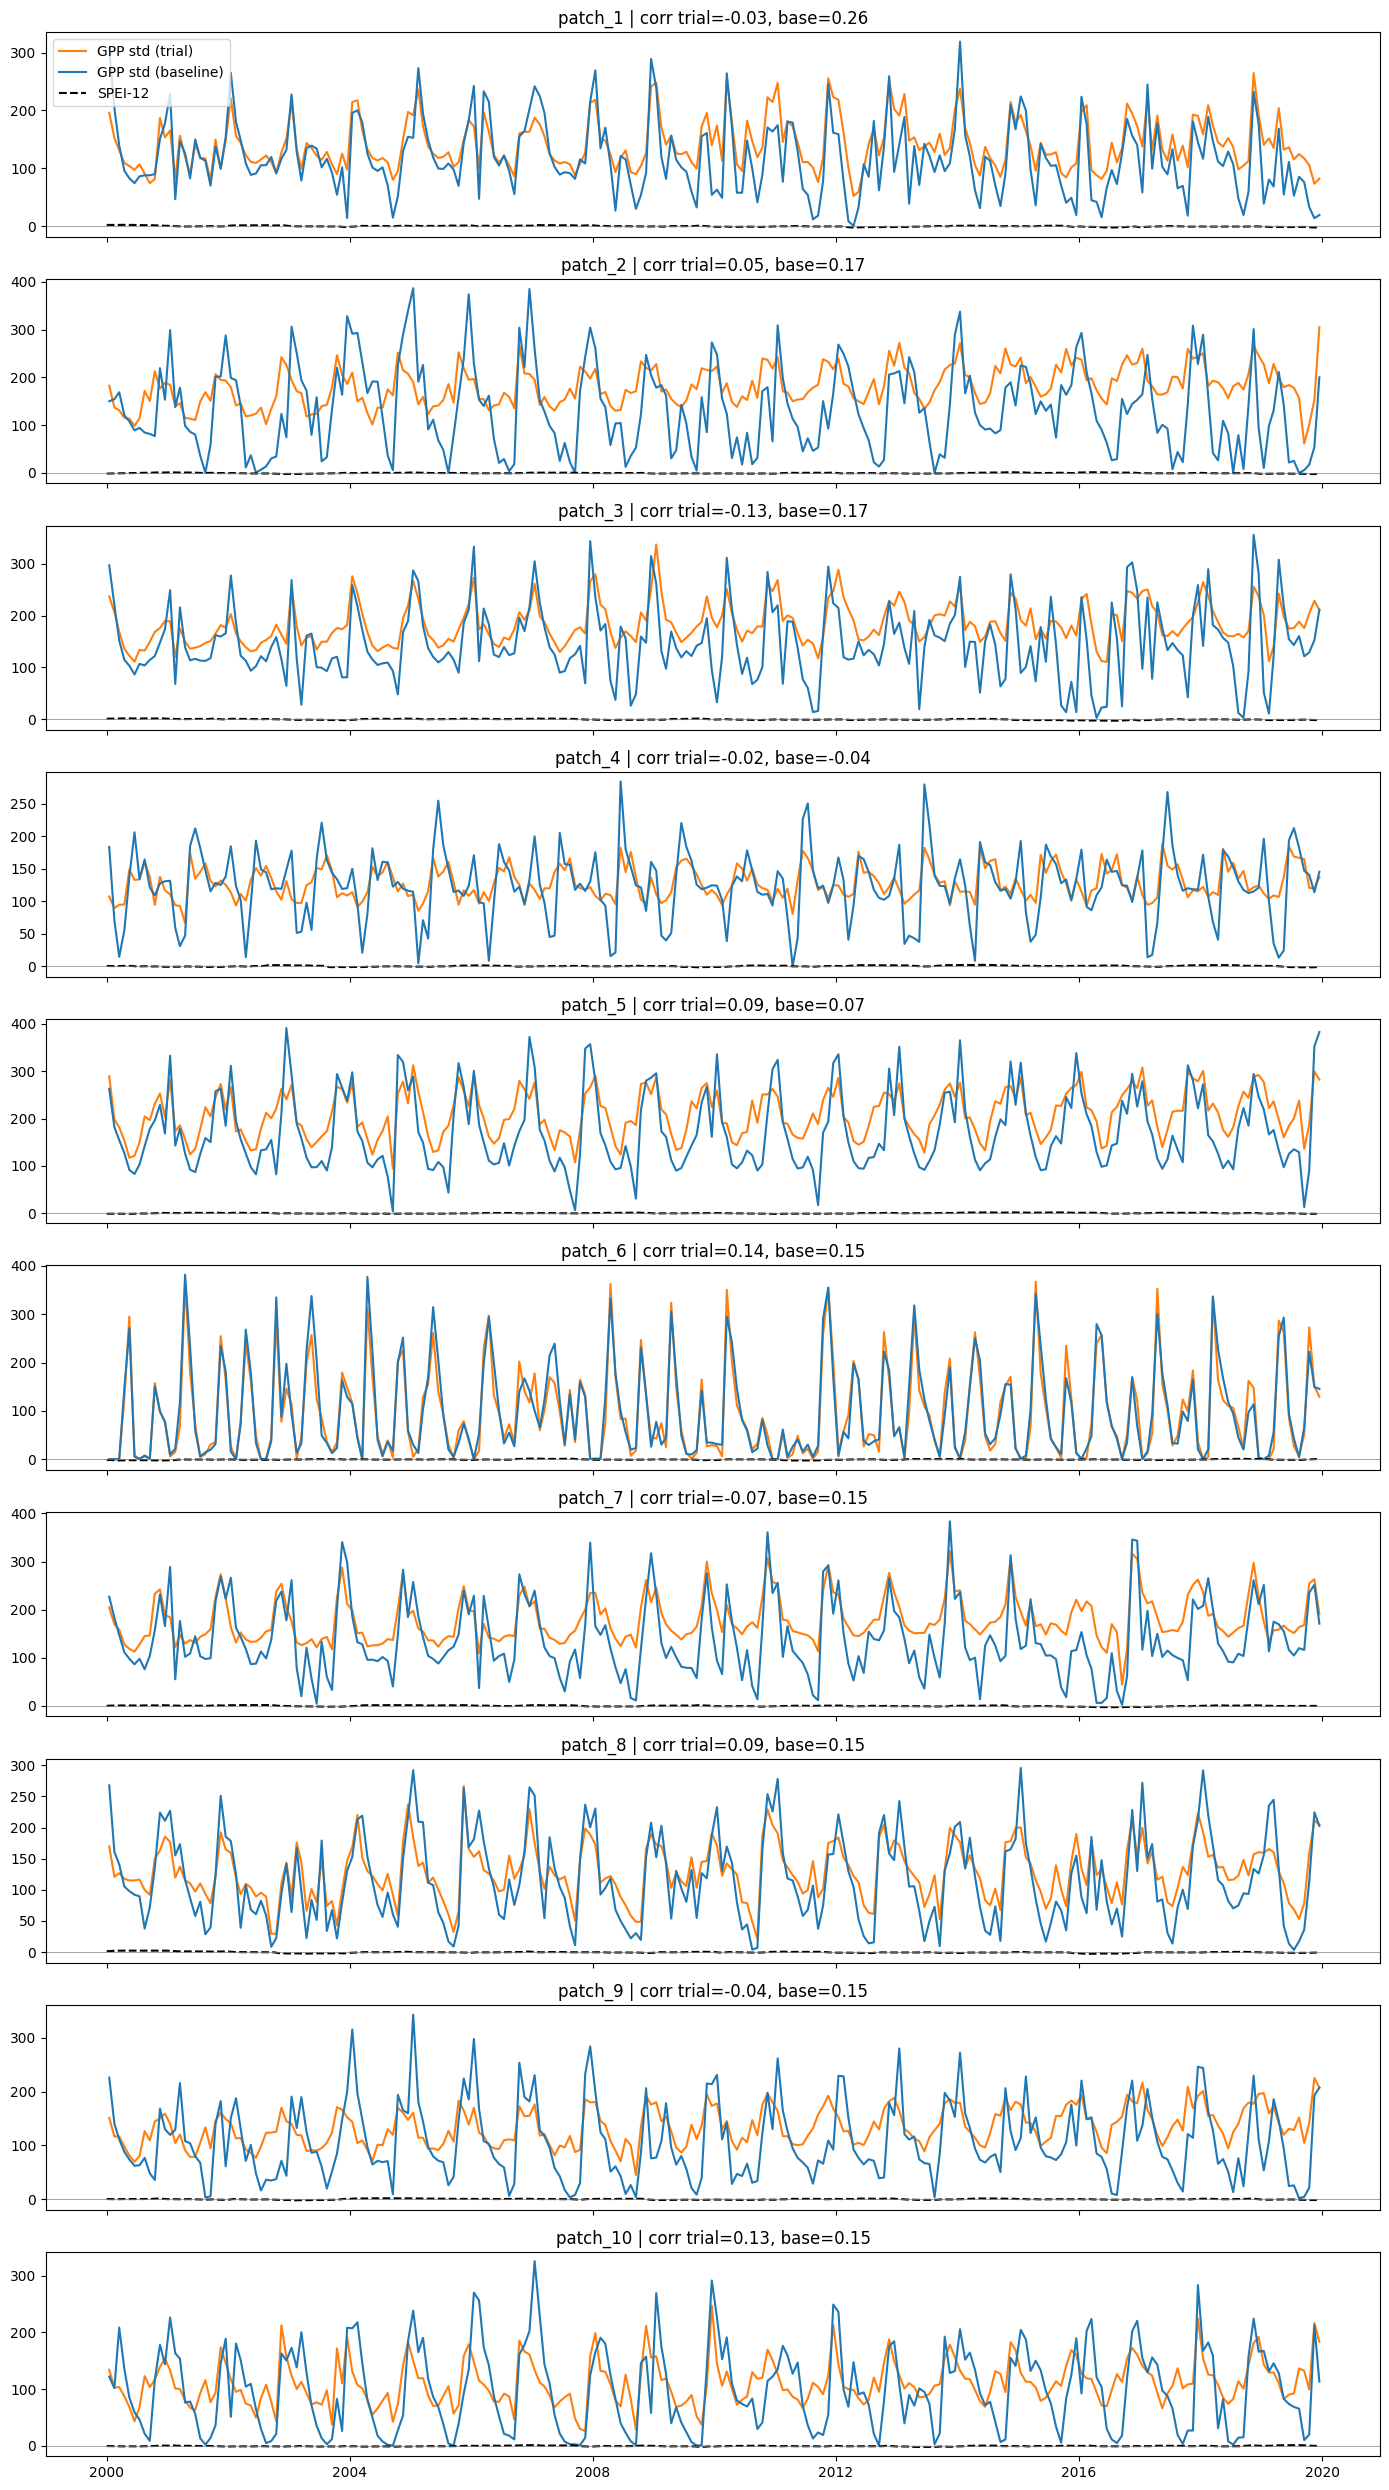

In [44]:
plot_temperate_nee_timeseries(
    knee_cache=knee_cache,
    OUTPUT_DIR=OUTPUT_DIR,
    BASELINE_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree/baseline_MM",
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=2000,
    END_YEAR=2019,
    standardized_anomalies=standardized_anomalies,
    n_patches=10
)

In [51]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


def plot_temperate_nee_timeseries(
    knee_cache,
    OUTPUT_DIR,
    BASELINE_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    standardized_anomalies,
    n_patches=10
):

    # -------------------------
    # correct PFT key from your dict
    # -------------------------
    pft_key = "temperate needleleaved evergreen tree"
    info = knee_cache[pft_key]
    trial = info["trial"]
    print(trial)
    

    trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

    sel_locs = locations[:n_patches]

    fig, axes = plt.subplots(n_patches, 1, figsize=(14, 2.5 * n_patches), sharex=True)
    if n_patches == 1:
        axes = [axes]

    spei = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    
    


    # -------------------------
    # helper correlation
    # -------------------------
    def corr(x, y):
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            return np.nan
        return np.corrcoef(x[mask], y[mask])[0, 1]

    for i, loc in enumerate(sel_locs):


        ax = axes[i]

        # =========================
        # TRIAL
        # =========================
        path = os.path.join(trial_dir, loc, "output")

        gpp = xr.open_dataset(os.path.join(path, "mgpp.nc")).GPP.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).rolling(time = 12).mean()

        # fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(
        #     time=slice(f"{START_YEAR}", f"{END_YEAR}")
        # )
        # fpc["pft"] = fpc.pft - 1

        # gpp_std = standardized_anomalies(
        #     (gpp / fpc.where(fpc > 1e-5))
        # ).isel(pft=2)
        
        gpp_std = standardized_anomalies(gpp.mean(dim=["lat", "lon"]).convert_calendar("standard"))

        spei_loc = spei.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

        # =========================
        # BASELINE
        # =========================
        base_path = os.path.join(BASELINE_DIR, loc, "output")

        gpp_b = xr.open_dataset(os.path.join(base_path, "mgpp.nc")).GPP.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).rolling(time = 12).mean()

        # fpc_b = xr.open_dataset(os.path.join(base_path, "fpc.nc")).FPC[:, 1:].sel(
        #     time=slice(f"{START_YEAR}", f"{END_YEAR}")
        # )
        # fpc_b["pft"] = fpc_b.pft - 1

        # gpp_std_b = standardized_anomalies(
        #     (gpp_b / fpc_b.where(fpc_b > 1e-5))
        # ).isel(pft=2)
        
        gpp_std_b = standardized_anomalies(gpp_b.mean(dim=["lat", "lon"]).convert_calendar("standard"))


        # # =========================
        # # align
        # # =========================
        # gpp_std = gpp_std.squeeze()
        # gpp_std_b = gpp_std_b.squeeze()
        # spei_loc = spei_loc.squeeze()

        # # keep only time dimension
        # gpp_std = gpp_std.dropna("time", how="all")
        # gpp_std_b = gpp_std_b.dropna("time", how="all")
        
        # -------------------------
        # collapse spatial dimensions FIRST
        # -------------------------
        gpp_std = gpp_std#.mean(dim=["lat", "lon"]).convert_calendar("standard")
        gpp_std_b = gpp_std_b#.mean(dim=["lat", "lon"]).convert_calendar("standard")
        spei_loc = spei_loc.mean(dim=["lat", "lon"])

        # now they are (time,) ONLY
        
        print(loc)

        # =========================
        # correlations
        # =========================
        c_trial = corr(gpp_std.values, spei_loc.values)
        c_base = corr(gpp_std_b.values, spei_loc.values)

        print(f"{loc} | trial: {c_trial:.3f} | baseline: {c_base:.3f}")

        # =========================
        # plot
        # =========================
        ax.plot(gpp_std.time, gpp_std, color="tab:orange", label="GPP std (trial)")
        ax.plot(gpp_std_b.time, gpp_std_b, color="tab:blue", label="GPP std (baseline)")
        ax.plot(spei_loc.time, spei_loc, color="black", linestyle="--", label="SPEI-12")

        ax.axhline(0, color="gray", linewidth=0.5)
        ax.set_title(f"{loc} | corr trial={c_trial:.2f}, base={c_base:.2f}")

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

0
patch_1
patch_1 | trial: -0.034 | baseline: 0.882
patch_2
patch_2 | trial: 0.093 | baseline: 0.678
patch_3
patch_3 | trial: -0.157 | baseline: 0.629
patch_4
patch_4 | trial: 0.126 | baseline: 0.241
patch_5
patch_5 | trial: 0.136 | baseline: 0.456
patch_6
patch_6 | trial: 0.775 | baseline: 0.800
patch_7
patch_7 | trial: -0.139 | baseline: 0.719
patch_8
patch_8 | trial: 0.523 | baseline: 0.788
patch_9
patch_9 | trial: -0.069 | baseline: 0.751
patch_10
patch_10 | trial: 0.367 | baseline: 0.745


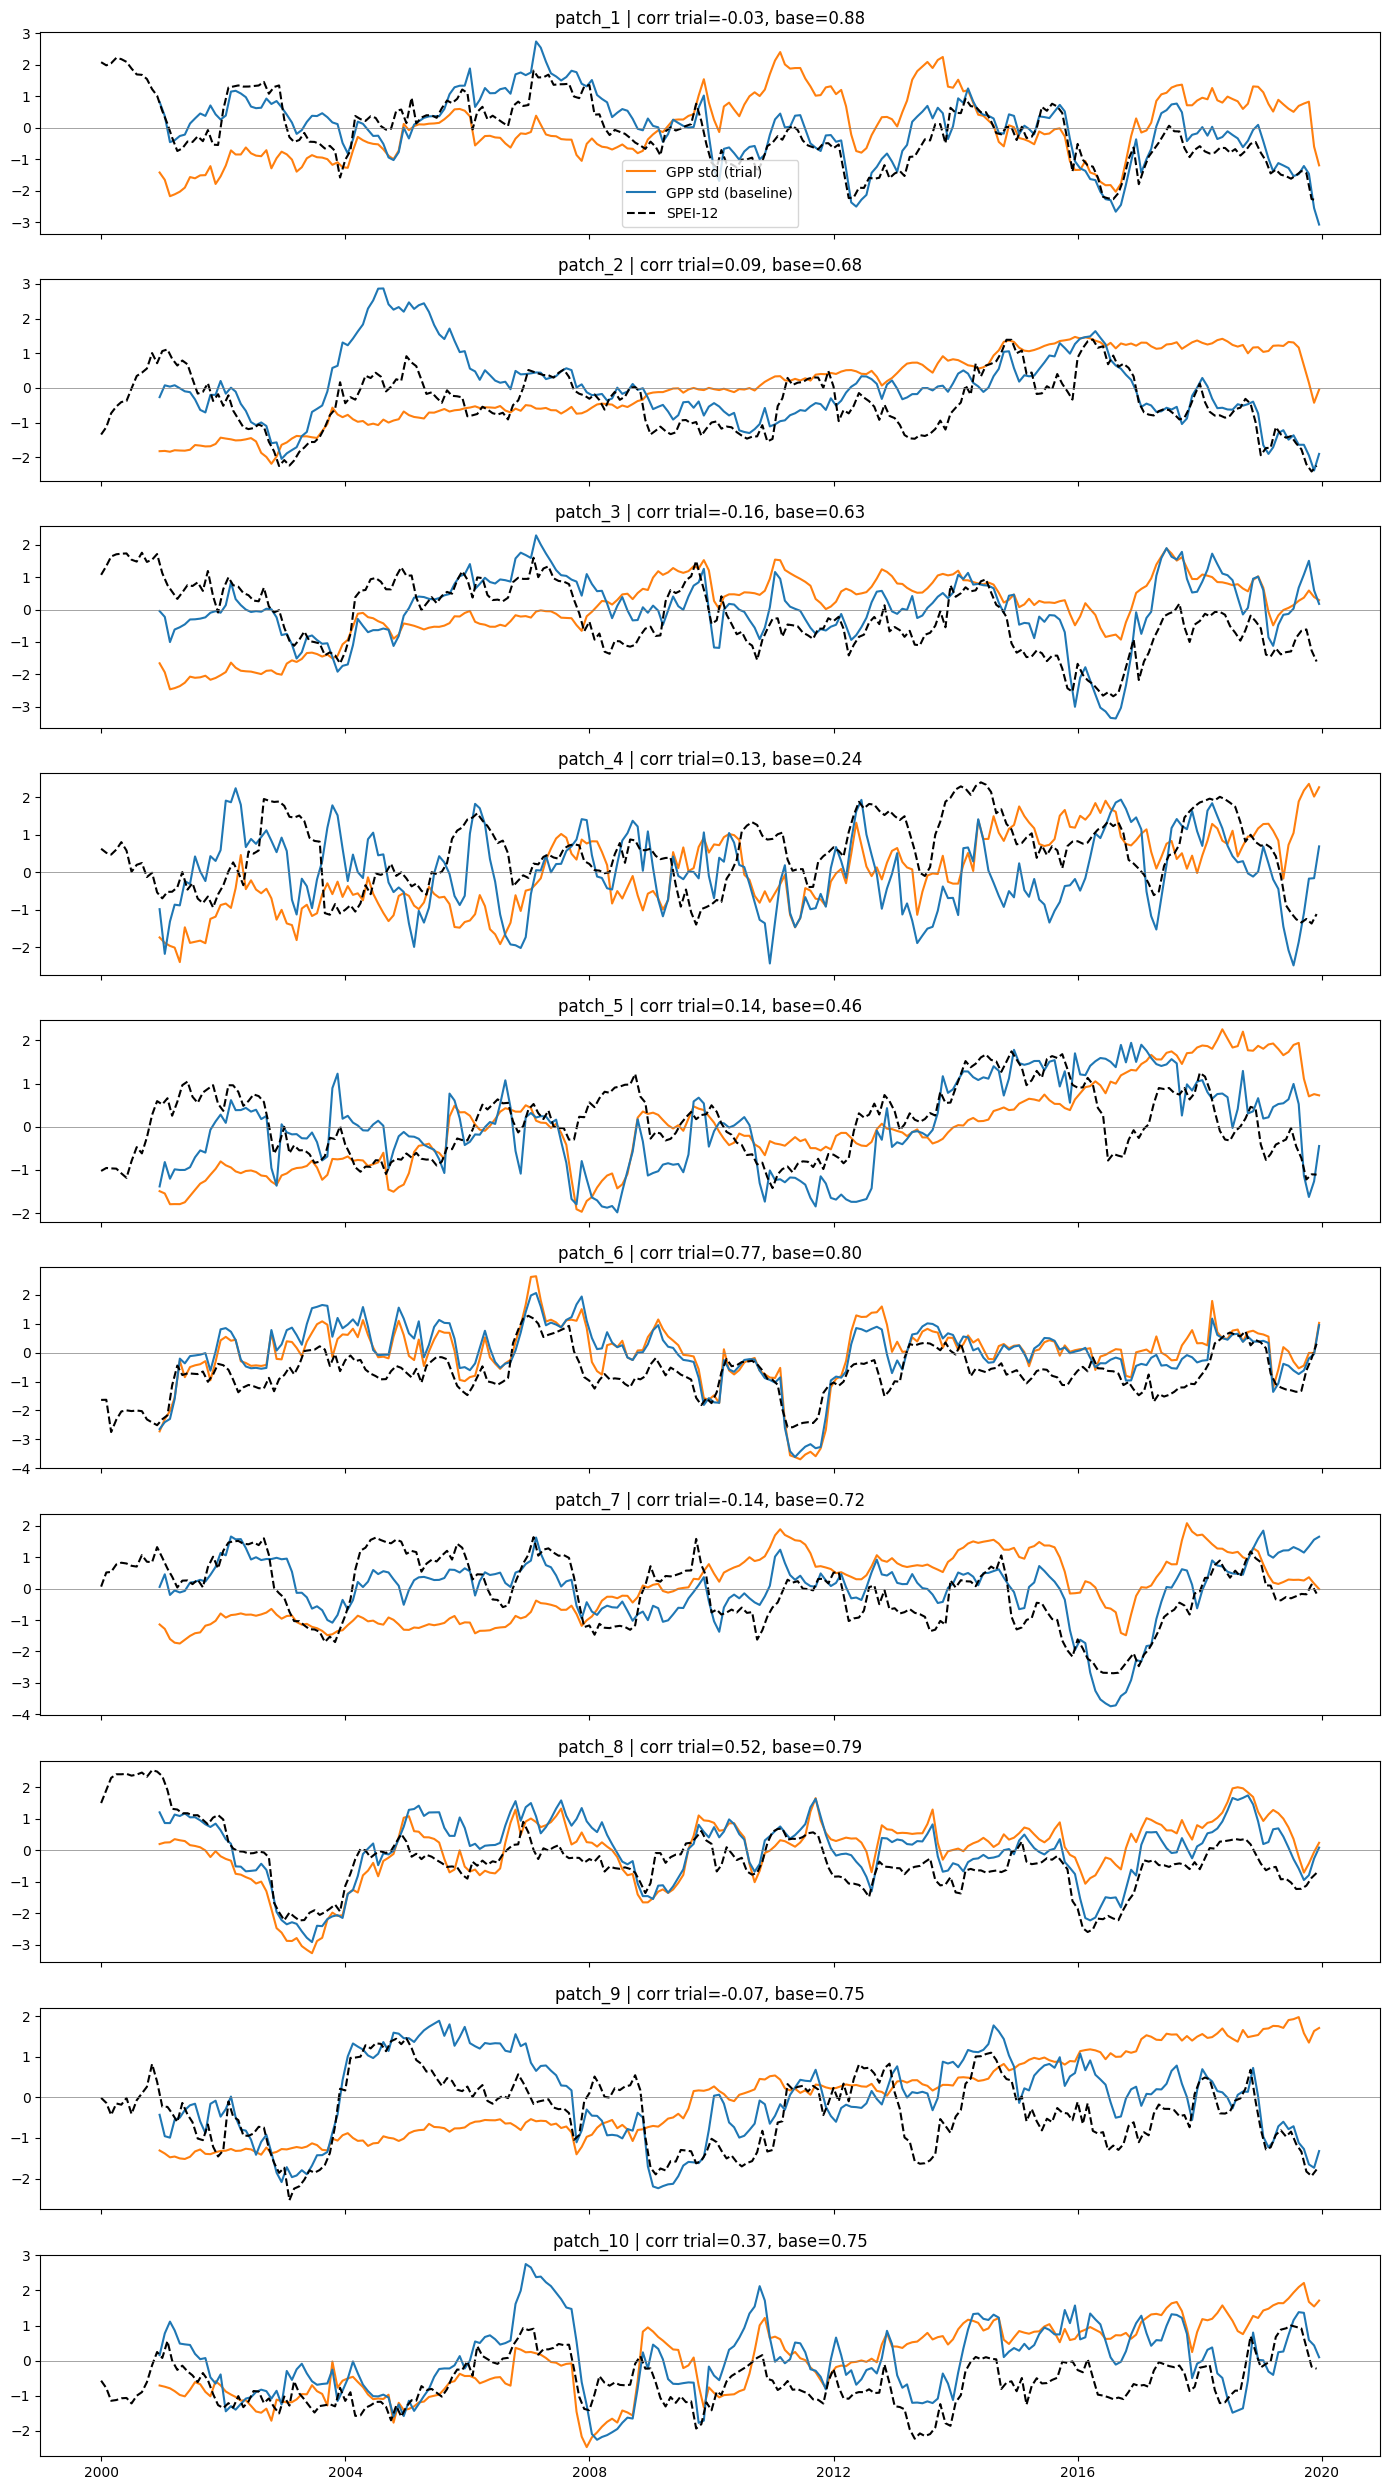

In [52]:
plot_temperate_nee_timeseries(
    knee_cache=knee_cache,
    OUTPUT_DIR=OUTPUT_DIR,
    BASELINE_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree/baseline_MM",
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=2000,
    END_YEAR=2019,
    standardized_anomalies=standardized_anomalies,
    n_patches=10
)

In [59]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


def plot_temperate_nee_timeseries(
    knee_cache,
    OUTPUT_DIR,
    BASELINE_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    standardized_anomalies,
    n_patches=10
):

    # -------------------------
    # correct PFT key from your dict
    # -------------------------
    pft_key = "temperate needleleaved evergreen tree"
    pft = 2  # correct PFT index for your case
    info = knee_cache[pft_key]
    trial = info["trial"]
    print(trial)
    

    trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

    sel_locs = locations[:n_patches]

    fig, axes = plt.subplots(n_patches, 1, figsize=(14, 2.5 * n_patches), sharex=True)
    if n_patches == 1:
        axes = [axes]

    spei = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    
    
    # -------------------------
    # helper correlation
    # -------------------------
    def corr(x, y):
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            return np.nan
        return np.corrcoef(x[mask], y[mask])[0, 1]

    for i, loc in enumerate(sel_locs):

        ax = axes[i]
        ax2 = ax.twinx()   # <-- secondary axis for SPEI

        # =========================
        # TRIAL
        # =========================
        path = os.path.join(trial_dir, loc, "output")

        mort = xr.open_dataset(os.path.join(path, "pft_mort.nc")).mortality.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).isel(pft=pft)

        spei_loc = spei.sel(lat=mort.lat, lon=mort.lon, method="nearest")

        # =========================
        # BASELINE
        # =========================
        base_path = os.path.join(BASELINE_DIR, loc, "output")

        mort_b = xr.open_dataset(os.path.join(base_path, "pft_mort.nc")).mortality.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).isel(pft=pft)

        # -------------------------
        # collapse spatial dims
        # -------------------------
        mort_log = mort.mean(dim=["lat", "lon"]).convert_calendar("standard")
        mort_b_log = mort_b.mean(dim=["lat", "lon"]).convert_calendar("standard")

        spei_loc = spei_loc.mean(dim=["lat", "lon"])

        # correlations (unchanged)
        c_trial = corr(mort_log.values, spei_loc.values)
        c_base = corr(mort_b_log.values, spei_loc.values)

        # =========================
        # PLOTTING
        # =========================
        ax.plot(mort_log.time, mort_log, color="tab:orange", label="Mortality (trial)")
        ax.plot(mort_b_log.time, mort_b_log, color="tab:blue", label="Mortality (baseline)")

        ax2.plot(spei_loc.time, spei_loc, color="black", linestyle="--", label="SPEI-12")

        ax.axhline(0, color="gray", linewidth=0.5)

        ax.set_title(f"{loc} | corr trial={c_trial:.2f}, base={c_base:.2f}")

        ax.set_ylabel("Mortality")
        ax2.set_ylabel("SPEI-12")

        # combine legends (important)
        if i == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    plt.show()

0


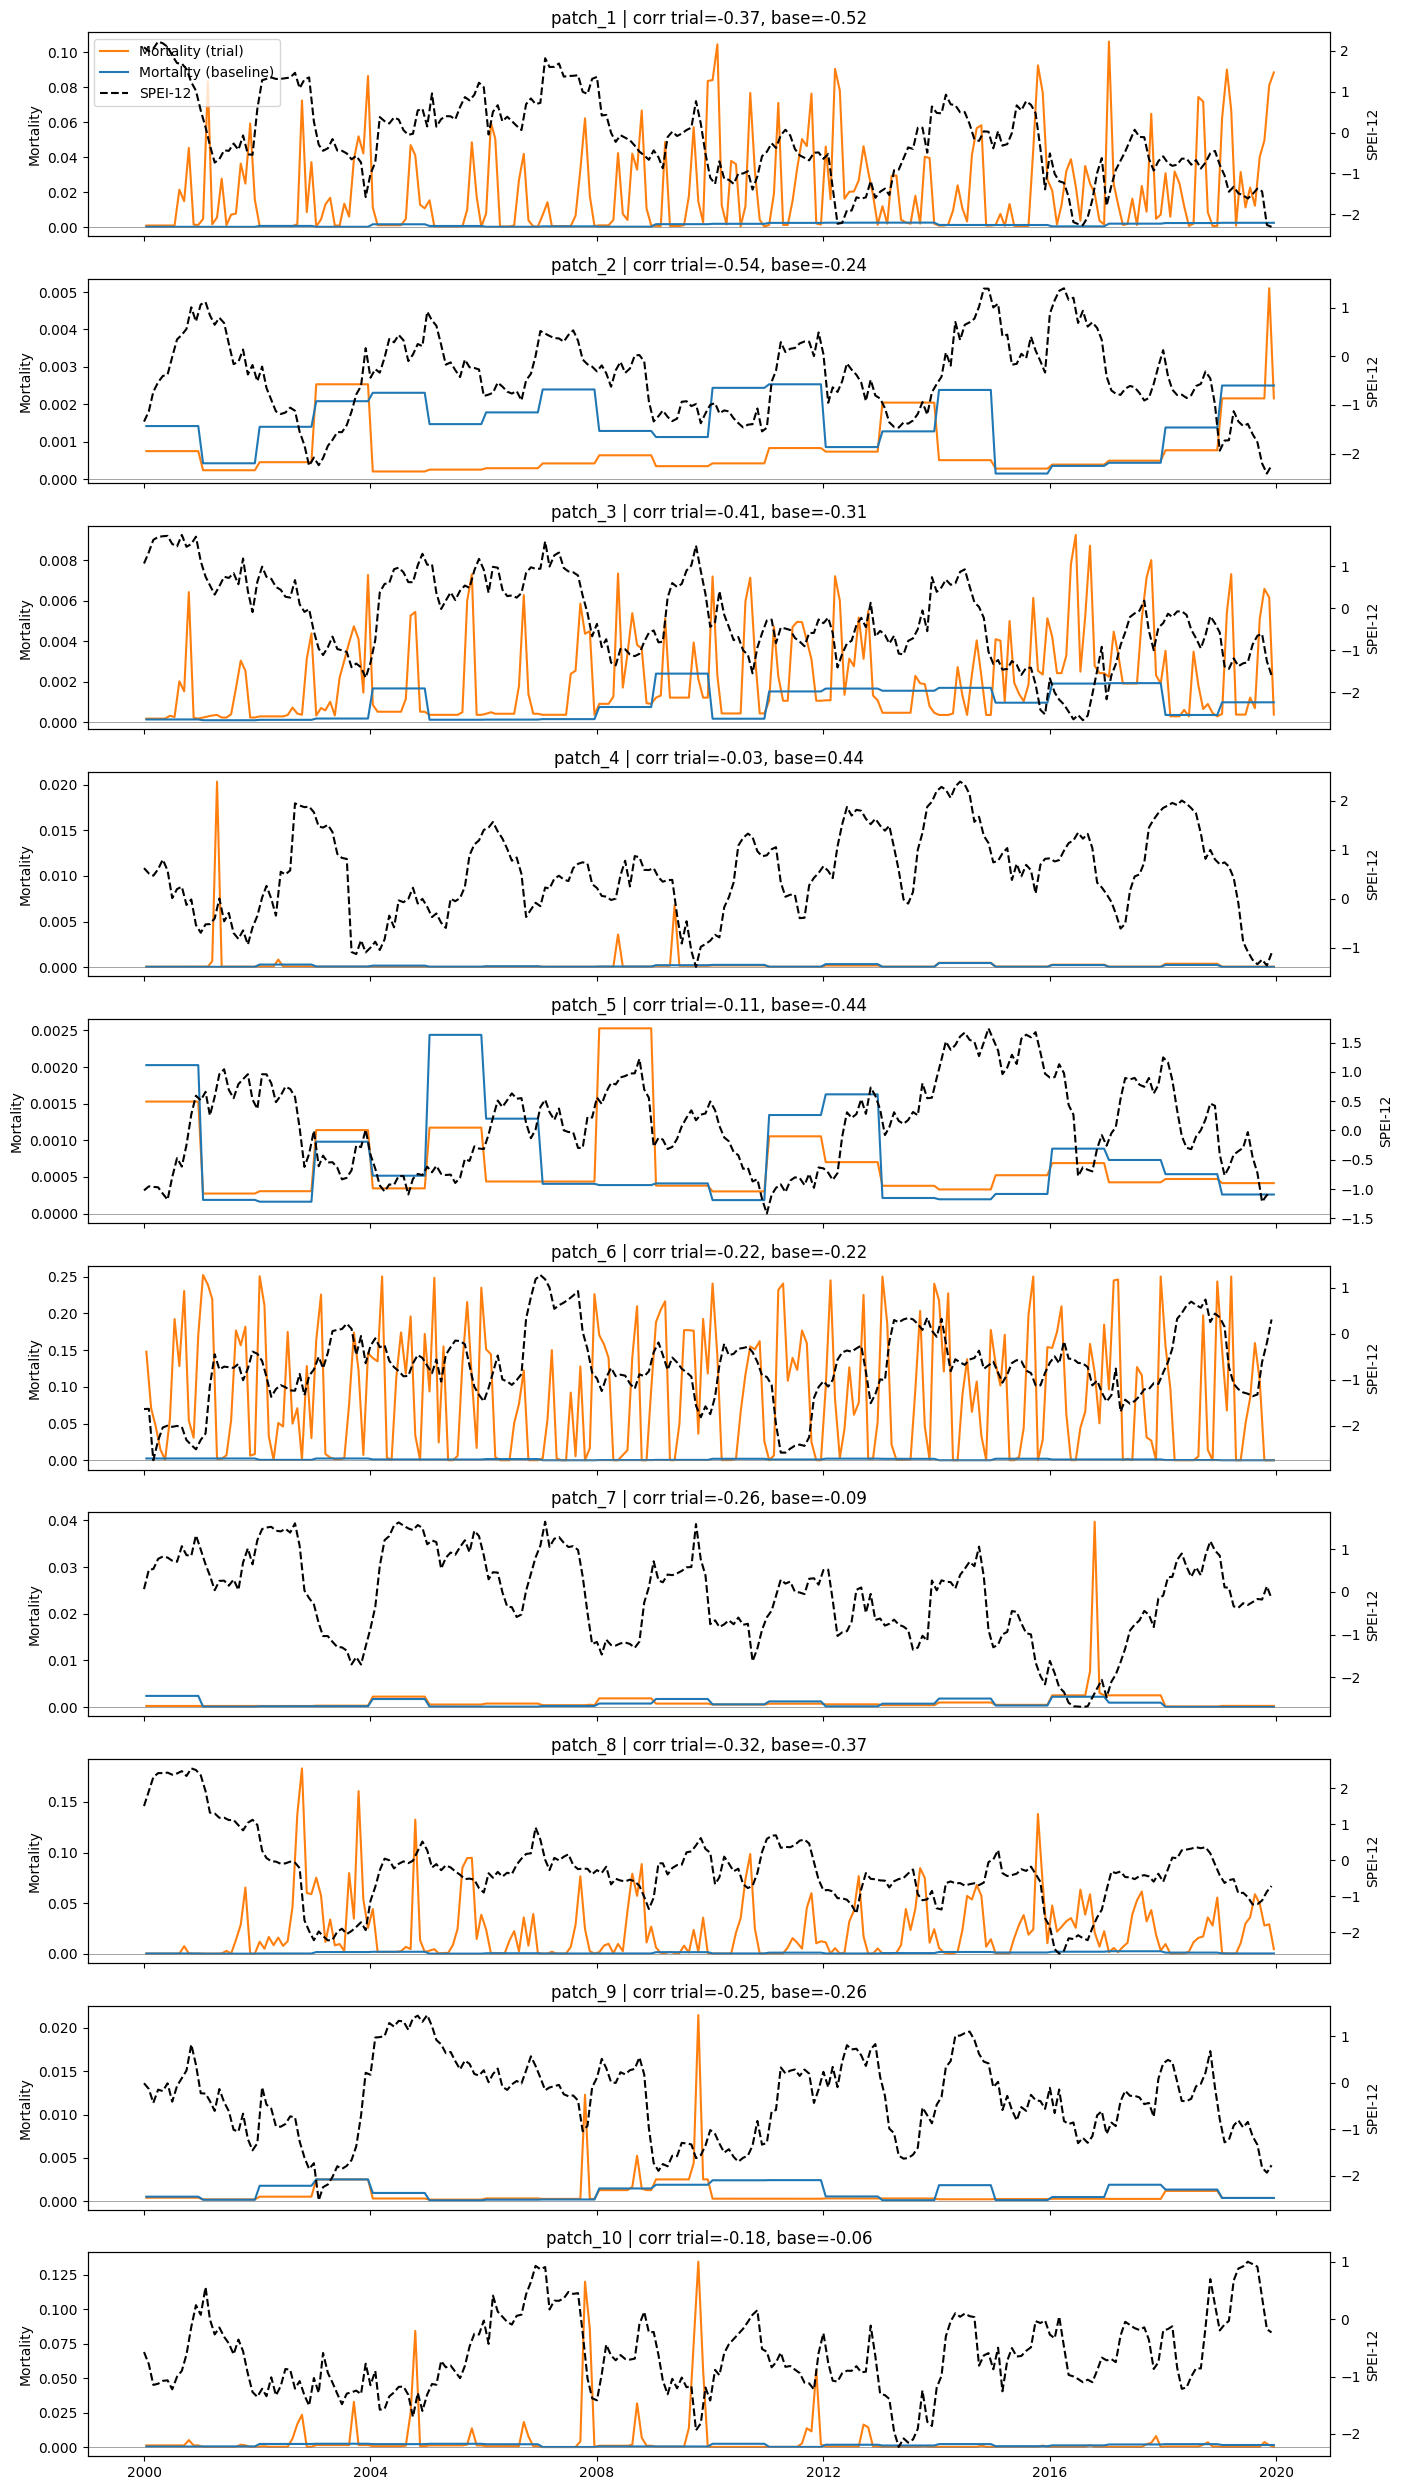

In [60]:
plot_temperate_nee_timeseries(
    knee_cache=knee_cache,
    OUTPUT_DIR=OUTPUT_DIR,
    BASELINE_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree/baseline_MM",
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=2000,
    END_YEAR=2019,
    standardized_anomalies=standardized_anomalies,
    n_patches=10
)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import os

locations = [
    "patch_1", "patch_2", "patch_3", "patch_4", "patch_5",
    "patch_6", "patch_7", "patch_8", "patch_9", "patch_10"
]
OUTPUT_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree"

def standardized_anomalies(data):
    data_ref = data.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m)/s if s!=0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )



obs_spei = xr.open_dataset(
    "/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc"
)["SPEI"]

S_obs_mort = -0.46
intercept_mort = -1.96

S_obs_gpp_water = {0:0.14,1:0.12,2:0.12,3:0.17,4:0.18,5:0.08,6:0.08,7:0.10}
intercept_gpp = {0:0.02,1:0.03,2:0.02,3:0.04,4:0.04,5:0.01,6:0.00,7:0.01}

START_YEAR = 2000
END_YEAR   = 2019

def plot_full_spei_scatter_gpp(trial_number, OUTPUT_DIR, locations, obs_spei, START_YEAR, END_YEAR, S_obs_gpp_water, intercept_gpp):

    trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial_number:04d}")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for pft_idx in range(8):

        gpp_vals = []
        spei_vals = []

        spei_local = obs_spei.sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        )

        # ==============================
        # LOOP OVER LOCATIONS
        # ==============================
        for loc in locations:

            out = os.path.join(trial_base, loc, "output")

            gpp = xr.open_dataset(os.path.join(out, "pft_gpp.nc")).GPP \
                .convert_calendar("standard") \
                .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
                .resample(time='MS').mean()

            fpc = xr.open_dataset(os.path.join(out, "fpc.nc")).FPC[:, 1:] \
                .convert_calendar("standard") \
                .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
                .resample(time='MS').mean()

            fpc['pft'] = fpc.pft - 1

            fpc_safe = fpc.where(fpc > 1e-5)
            gpp_per_fpc = gpp / fpc_safe

            gpp_std = standardized_anomalies(gpp_per_fpc)

            spei_loc = spei_local.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

            # flatten FULL spatial + time structure (NO averaging)
            spei_flat = spei_loc.values.flatten()
            gpp_flat = gpp_std.isel(pft=pft_idx).values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)

            gpp_vals.append(gpp_flat[mask])
            spei_vals.append(spei_flat[mask])

        # ==============================
        # MERGE ALL LOCATIONS
        # ==============================
        gpp_all = np.concatenate(gpp_vals)
        spei_all = np.concatenate(spei_vals)

        ax = axes[pft_idx]

        ax.scatter(spei_all, gpp_all, s=5, alpha=0.2)

        # regression line (model)
        if len(spei_all) > 10:
            m, b = np.polyfit(spei_all, gpp_all, 1)
            x = np.linspace(np.nanmin(spei_all), np.nanmax(spei_all), 100)
            ax.plot(x, m * x + b, color="red")

        # observed line
        x = np.linspace(np.nanmin(spei_all), np.nanmax(spei_all), 100)
        ax.plot(
            x,
            S_obs_gpp_water[pft_idx] * x + intercept_gpp[pft_idx],
            color="black",
            linewidth=2
        )

        ax.set_title(f"PFT {pft_idx}")
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)

    plt.suptitle(f"FULL spatial SPEI–GPP scatter (no averaging) – trial {trial_number}")
    plt.tight_layout()
    plt.show()

/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

ValueError: zero-size array to reduction operation fmin which has no identity

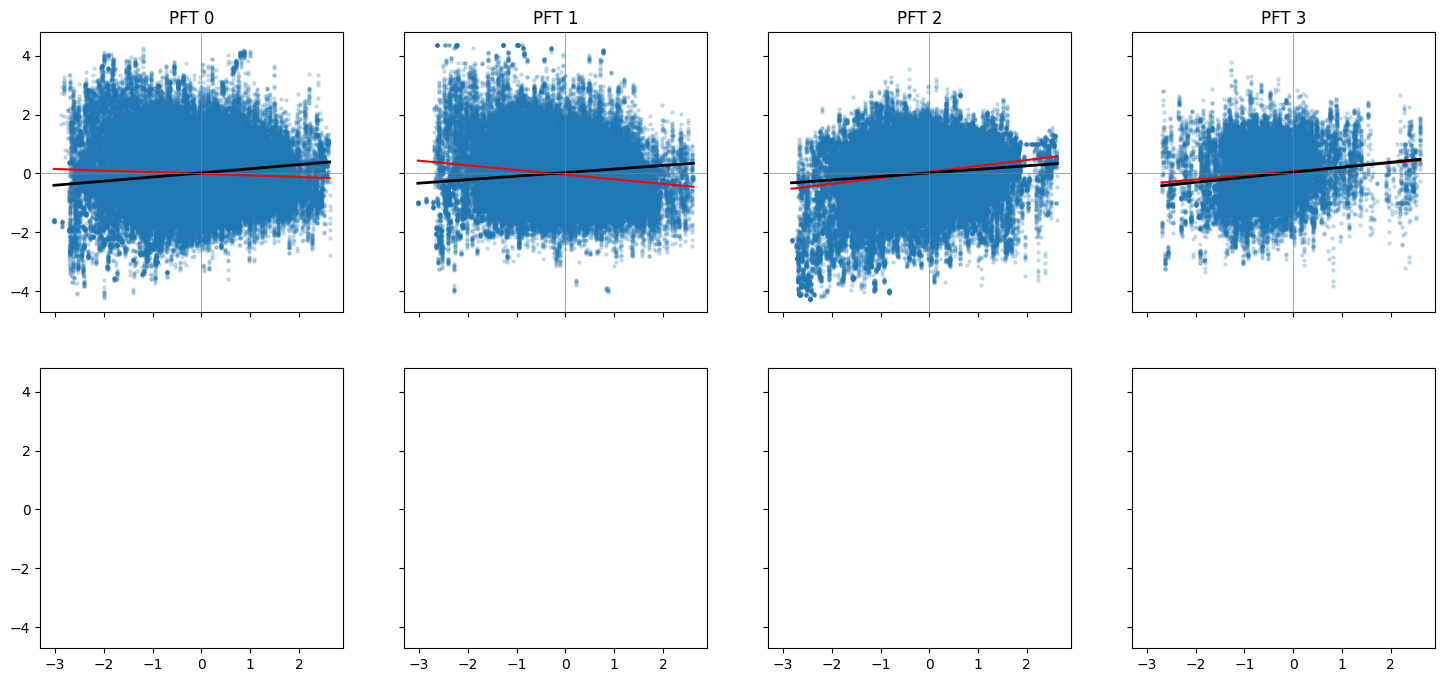

In [33]:
plot_full_spei_scatter_gpp(
    trial_number=60,
    OUTPUT_DIR=OUTPUT_DIR,
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=START_YEAR,
    END_YEAR=END_YEAR,
    S_obs_gpp_water=S_obs_gpp_water,
    intercept_gpp=intercept_gpp
)

In [41]:
def get_best_trials(df):

    best_trials = {}

    for pft in df["pft"].unique():

        out = interactive_pareto_for_pft(df, pft)

        if out is None:
            continue

        wide, knee_trial = out

        best_trials[pft] = knee_trial
        
    print("Best trials per PFT:")
    for k, v in best_trials.items():
        print(k, "→", v)

    return best_trials

Best trials per PFT:


NameError: name 'best_trials' is not defined

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def plot_best_pareto_spei_scatter(
    df,
    OUTPUT_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp
):

    best_trials = get_best_trials(df)

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    spei_local = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))

    for pft_idx in range(8):

        ax = axes[pft_idx]

        if pft_idx not in best_trials:
            ax.set_title(f"PFT {pft_idx} (no trial)")
            continue

        trial = best_trials[pft_idx]
        trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

        gpp_all = []
        spei_all = []

        for loc in locations:

            out = os.path.join(trial_base, loc, "output")

            gpp = xr.open_dataset(os.path.join(out, "pft_gpp.nc")).GPP \
                .convert_calendar("standard") \
                .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
                .resample(time="MS").mean()

            fpc = xr.open_dataset(os.path.join(out, "fpc.nc")).FPC[:, 1:] \
                .convert_calendar("standard") \
                .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
                .resample(time="MS").mean()

            fpc["pft"] = fpc.pft - 1
            gpp_std = standardized_anomalies(gpp / fpc.where(fpc > 1e-5))

            spei_loc = spei_local.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

            spei_flat = spei_loc.values.flatten()
            gpp_flat = gpp_std.isel(pft=pft_idx).values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)

            gpp_all.append(gpp_flat[mask])
            spei_all.append(spei_flat[mask])

        gpp_all = np.concatenate(gpp_all)
        spei_all = np.concatenate(spei_all)

        ax.scatter(spei_all, gpp_all, s=5, alpha=0.2)

        # model fit
        if len(spei_all) > 10:
            m, b = np.polyfit(spei_all, gpp_all, 1)
            x = np.linspace(np.nanmin(spei_all), np.nanmax(spei_all), 100)
            ax.plot(x, m * x + b, color="red")

        # observed
        x = np.linspace(np.nanmin(spei_all), np.nanmax(spei_all), 100)
        ax.plot(
            x,
            S_obs_gpp_water[pft_idx] * x + intercept_gpp[pft_idx],
            color="black",
            linewidth=2
        )

        ax.set_title(f"PFT {pft_idx}\n(best trial {trial})")

    plt.suptitle("SPEI–GPP using Pareto-knee (blue point) trials")
    plt.tight_layout()
    plt.show()


Pareto-optimal trials (water-limited) – tropical broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_evergreen_tree  beta_tropical_broadleaved_evergreen_tree
    46   0.051836 0.320274                                   0.013497                                  3.055370
    33   0.071491 0.278389                                   0.017430                                 16.921387
    10   0.085996 0.264026                                   0.021942                                 15.637667
     3   0.196146 0.182195                                   0.078543                                 23.926931
    68   0.196309 0.181977                                   0.078543                                 24.522116
    66   0.213906 0.155067                                   0.113070                                 21.528777



Pareto-optimal trials (water-limited) – tropical broadleaved raingreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_raingreen_tree  beta_tropical_broadleaved_raingreen_tree
    46   0.061491 0.356265                                   0.085588                                  6.525343
    68   0.192023 0.222690                                   0.333952                                 10.047270
     3   0.192293 0.221977                                   0.333952                                 10.047270



Pareto-optimal trials (water-limited) – temperate needleleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_needleleaved_evergreen_tree  beta_temperate_needleleaved_evergreen_tree
    18   0.007266 0.844117                                     0.295681                                    8.377819
    67   0.013695 0.794467                                     0.297046                                    6.730302
    74   0.014235 0.647280                                     0.365005                                    5.189501
     5   0.048913 0.193884                                     0.149078                                    2.766237
     0   0.059742 0.154953                                     0.137467                                   16.446453
    43   0.119131 0.134971                                     0.147778                                    1.925742
    42   0.269271 0.085345                                     0.182270                                    3.


Pareto-optimal trials (water-limited) – temperate broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_broadleaved_evergreen_tree  beta_temperate_broadleaved_evergreen_tree
    10   0.024740 1.924123                                    0.884890                                   0.665707
    47   0.047366 1.125708                                    0.242378                                  16.504654
    60   0.054871 1.084861                                    0.264727                                  19.842650
    30   0.058400 0.873808                                    0.191600                                  17.955877
    49   0.060515 0.526923                                    0.405771                                   0.179267
    37   0.072811 0.480362                                    0.052644                                   9.455035
    15   0.073489 0.448876                                    0.136454                                  16.053039
    29   0

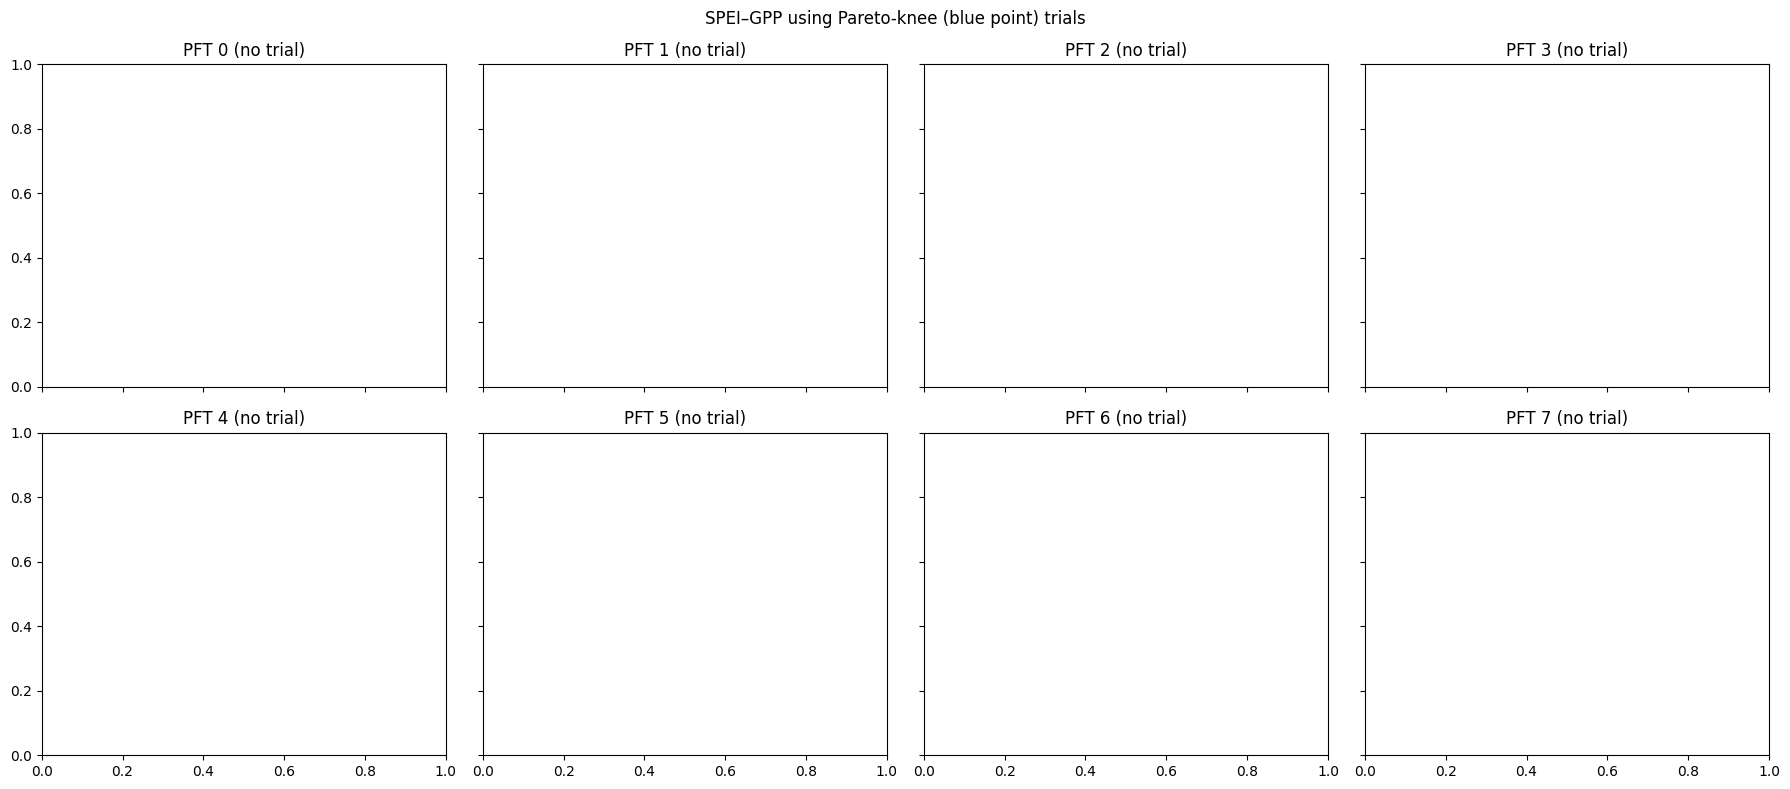

In [43]:
plot_best_pareto_spei_scatter(
    df,
    OUTPUT_DIR,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp
)

In [ ]:
xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree/trial_0060/patch_6/output/pft_mort.nc")

<xarray.DataArray 'GPP' (time: 720, pft: 43, lat: 9, lon: 7)> Size: 8MB
[1950480 values with dtype=float32]
Coordinates:
  * time     (time) object 6kB 1960-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 172B 1 2 3 4 5 6 7 8 9 ... 35 36 37 38 39 40 41 42 43
  * lat      (lat) float64 72B 4.05 4.15 4.25 4.35 4.45 4.55 4.65 4.75 4.85
  * lon      (lon) float64 56B 38.15 38.25 38.35 38.45 38.55 38.65 38.75
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

In [3]:
obs_spei = xr.open_dataset(
    "/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc"
)["SPEI"]

aridity = xr.open_dataset(
    "/projects/prjs2023/chapter3/aridity/aridity_mean_0_1_degree.nc"
).__xarray_dataarray_variable__

aridity['lon'] = obs_spei['lon']
aridity['lat'] = obs_spei['lat']

S_obs_mort = -0.46
intercept_mort = -1.96

S_obs_gpp_water = {0:0.14,1:0.12,2:0.12,3:0.17,4:0.18,5:0.08,6:0.08,7:0.10}
intercept_gpp = {0:0.02,1:0.03,2:0.02,3:0.04,4:0.04,5:0.01,6:0.00,7:0.01}

pfts = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree"
]

START_YEAR = 2000
END_YEAR   = 2019

def yearly_mean(da):
    return da.resample(time="YS").mean()


def compute_gpp_objectives(trial_number):
    trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial_number:04d}")

    gpp_vals = {pft: [] for pft in range(8)}
    spei_vals = {pft: [] for pft in range(8)}

    # Prepare SPEI once
    spei_local = obs_spei.sel(
        time=slice(f"{START_YEAR}", f"{END_YEAR}")
    )#.resample(time='MS').mean()

    for loc in locations:
        out = os.path.join(trial_base, loc, "output")

        gpp = xr.open_dataset(os.path.join(out, "pft_gpp.nc")).GPP \
            .convert_calendar("standard") \
            .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
            .resample(time='MS').mean()

        fpc = xr.open_dataset(os.path.join(out, "fpc.nc")).FPC[:, 1:] \
            .convert_calendar("standard") \
            .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
            .resample(time='MS').mean()

        fpc['pft'] = fpc.pft - 1

        fpc_safe = fpc.where(fpc > 1e-5)
        gpp_per_fpc = gpp / fpc_safe

        gpp_std = standardized_anomalies(gpp_per_fpc)

        spei_loc = spei_local.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

        spei_flat = spei_loc.values.flatten()

        for pft_idx in range(8):
            gpp_flat = gpp_std.isel(pft=pft_idx).values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)

            gpp_vals[pft_idx].append(gpp_flat[mask])
            spei_vals[pft_idx].append(spei_flat[mask])

    # ==============================
    # Compute slopes
    # ==============================
    slopes = {}
    objectives = []

    for pft_idx in range(8):
        gpp_all = np.concatenate(gpp_vals[pft_idx])
        spei_all = np.concatenate(spei_vals[pft_idx])

        mask = np.isfinite(gpp_all) & np.isfinite(spei_all)

        if mask.sum() > 10:
            S_fit, b_fit = np.polyfit(spei_all[mask], gpp_all[mask], 1)

            slopes[pft_idx] = {"slope": S_fit, "intercept": b_fit}

            y_model = S_fit * spei_all[mask] + b_fit
            y_obs = (
                S_obs_gpp_water[pft_idx] * spei_all[mask]
                + intercept_gpp[pft_idx]
            )

            rmse = np.sqrt(np.mean((y_model - y_obs) ** 2))
            objectives.append(rmse)

        else:
            slopes[pft_idx] = {"slope": np.nan, "intercept": np.nan}
            objectives.append(1e6)

    return slopes, objectives



def compute_mortality_objectives(trial_number):
    trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial_number:04d}")

    mort_vals = {pft: [] for pft in range(8)}
    spei_vals = {pft: [] for pft in range(8)}

    spei_local = obs_spei.sel(
        time=slice(f"{START_YEAR}", f"{END_YEAR}")
    ).resample(time='YS').mean()

    for loc in locations:
        out = os.path.join(trial_base, loc, "output")

        mort = xr.open_dataset(os.path.join(out, "pft_mort.nc")).mortality \
            .convert_calendar("standard") \
            .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
            .resample(time="YS").sum()

        spei_loc = spei_local.sel(lat=mort.lat, lon=mort.lon, method="nearest")

        spei_flat = spei_loc.values.flatten()

        for pft_idx in range(8):
            mort_flat = mort.isel(pft=pft_idx).values.flatten()

            # log transform
            mort_flat = np.log10(mort_flat)

            mask = np.isfinite(mort_flat) & np.isfinite(spei_flat)

            mort_vals[pft_idx].append(mort_flat[mask])
            spei_vals[pft_idx].append(spei_flat[mask])

    # ==============================
    # Compute slopes
    # ==============================
    slopes = {}
    objectives = []

    for pft_idx in range(8):
        mort_all = np.concatenate(mort_vals[pft_idx])
        spei_all = np.concatenate(spei_vals[pft_idx])

        mask = np.isfinite(mort_all) & np.isfinite(spei_all)

        if mask.sum() > 10:
            S_fit, b_fit = np.polyfit(spei_all[mask], mort_all[mask], 1)

            slopes[pft_idx] = {"slope": S_fit, "intercept": b_fit}

            y_model = S_fit * spei_all[mask] + b_fit
            y_obs = S_obs_mort * spei_all[mask] + intercept_mort

            rmse = np.sqrt(np.mean((y_model - y_obs) ** 2))
            objectives.append(rmse)

        else:
            slopes[pft_idx] = {"slope": np.nan, "intercept": np.nan}
            objectives.append(1e6)

    return slopes, objectives

    
def standardized_anomalies(data, start_year=START_YEAR, end_year=END_YEAR):
    data_ref = data.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m) / s if s != 0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.colors as colors
import matplotlib.cm as cm

# ------------------------------------------------------------
# PFT -> (alpha column, beta column) mapping
# ------------------------------------------------------------

pft_to_param = {
    "tropical broadleaved evergreen tree": (
        "alpha_tropical_broadleaved_evergreen_tree",
        "beta_tropical_broadleaved_evergreen_tree",
    ),
    "tropical broadleaved raingreen tree": (
        "alpha_tropical_broadleaved_raingreen_tree",
        "beta_tropical_broadleaved_raingreen_tree",
    ),
    "temperate needleleaved evergreen tree": (
        "alpha_temperate_needleleaved_evergreen_tree",
        "beta_temperate_needleleaved_evergreen_tree",
    ),
    "temperate broadleaved evergreen tree": (
        "alpha_temperate_broadleaved_evergreen_tree",
        "beta_temperate_broadleaved_evergreen_tree",
    ),
    "temperate broadleaved summergreen tree": (
        "alpha_temperate_broadleaved_summergreen_tree",
        "beta_temperate_broadleaved_summergreen_tree",
    ),
    "boreal needleleaved evergreen tree": (
        "alpha_boreal_needleleaved_evergreen_tree",
        "beta_boreal_needleleaved_evergreen_tree",
    ),
    "boreal broadleaved summergreen tree": (
        "alpha_boreal_broadleaved_summergreen_tree",
        "beta_boreal_broadleaved_summergreen_tree",
    ),
    "boreal needleleaved summergreen tree": (
        "alpha_boreal_needleleaved_summergreen_tree",
        "beta_boreal_needleleaved_summergreen_tree",
    ),
}

# ------------------------------------------------------------
# Low-level helper: contour + scatter, no df modification
# ------------------------------------------------------------

def _contour_with_scatter(df_sub, alpha_col, beta_col, ax, title, norm, cmap):
    x = df_sub[alpha_col].values
    y = df_sub[beta_col].values
    z = df_sub["loss"].values

    # drop NaNs in loss
    mask = ~np.isnan(z)
    x, y, z = x[mask], y[mask], z[mask]

    if len(z) < 5:
        ax.set_title(title + "\n(not enough data)")
        ax.set_xlabel("alpha")
        ax.set_ylabel("beta")
        return None

    # grid for contour
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata((x, y), z, (Xi, Yi), method="linear")

    # contour with shared norm + cmap
    cs = ax.contourf(
        Xi, Yi, Zi,
        levels=20,
        norm=norm,
        cmap=cmap,
    )

    # overlay scatter points (same norm + cmap)
    ax.scatter(
        x, y,
        c=z,
        s=20,
        edgecolor="k",
        linewidth=0.3,
        norm=norm,
        cmap=cmap,
    )

    ax.set_xlabel("alpha")
    ax.set_ylabel("beta")
    ax.set_title(title)

    return cs

# ------------------------------------------------------------
# Main panel function (your calling style)
# ------------------------------------------------------------

def panel_alpha_beta_contours(df, pft, gpp_col="GPP_water"):
    """
    1x2 panel for one PFT:
      - left: GPP_water loss surface + scatter
      - right: MORT loss surface + scatter

    If no valid GPP data, prints table of best points (lowest mortality loss) but still plots.
    """

    if pft not in pft_to_param:
        raise ValueError(f"PFT not in mapping: {pft}")

    alpha_col, beta_col = pft_to_param[pft]

    # Filter data
    df_gpp = df[(df["pft"] == pft) & (df["process"] == gpp_col)]
    df_mort = df[(df["pft"] == pft) & (df["process"] == "MORT")]

    # Shared color scale across both panels
    all_loss = pd.concat([df_gpp["loss"], df_mort["loss"]]).values
    all_loss = all_loss[~np.isnan(all_loss)]

    if len(all_loss) == 0:
        print(f"\n⚠️ No valid data for PFT = {pft}")
        return

    vmin = all_loss.min()
    vmax = all_loss.max()

    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap("viridis")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # ---- GPP panel ----
    cs_gpp = _contour_with_scatter(
        df_gpp,
        alpha_col, beta_col,
        ax=axes[0],
        title=f"{pft}\nGPP water loss",
        norm=norm,
        cmap=cmap,
    )

    # If no valid GPP points, print best mortality points
    if df_gpp["loss"].dropna().empty and not df_mort.empty:
        print(f"\n⚠️ No valid GPP data for PFT = {pft}")
        best_mort = df_mort.sort_values("loss").head(5)
        print("Top mortality loss points (lowest loss):")
        display(best_mort[[alpha_col, beta_col, "loss"]])

    # ---- Mortality panel ----
    cs_mort = _contour_with_scatter(
        df_mort,
        alpha_col, beta_col,
        ax=axes[1],
        title=f"{pft}\nMortality loss",
        norm=norm,
        cmap=cmap,
    )

    # ---- Shared colorbar ----
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, orientation="vertical", shrink=0.9, label="loss")

    plt.suptitle(f"Alpha–Beta loss surfaces for PFT = {pft}", fontsize=14)
    plt.show()




In [6]:
def plot_spei_yearly_gpp_mort_all_pfts(df, trial_dir_template):

    for pft_name in pfts:
        START_YEAR = 2000
        END_YEAR = 2019
        print(f"\n🔹 Processing {pft_name}")

        best = pareto_table_for_pft(df, pft_name)
        if best is None or best.empty:
            print(f"⏭️ No Pareto-optimal trials for {pft_name}")
            continue

        three_quarters_idx = (1 * len(best)) // 1
        if three_quarters_idx >= len(best):
            three_quarters_idx = len(best) - 1
        trial_num = best["trial"].iloc[three_quarters_idx]
        print(f"   Using 1/1 Pareto-optimal trial ({three_quarters_idx+1}/{len(best)}): {trial_num}")
        
        # middle_idx = len(best) // 2
        # trial_num = best["trial"].iloc[middle_idx]
        # print(f"   Using middle Pareto-optimal trial ({middle_idx+1}/{len(best)}): {trial_num}")
        
        # best = best.sort_values("MORT")

        knee = select_knee_point(best, gpp_col="GPP_water", mort_col="MORT")
        trial_num = int(knee["trial"])
        print("Using weighted knee-point trial:", trial_num)

        alpha_col, beta_col = pft_to_param[pft_name]
        df_trial_pft = df[(df["trial"] == trial_num) & (df["pft"] == pft_name)]

        if not df_trial_pft.empty:
            alpha_val = df_trial_pft[alpha_col].values[0]
            beta_val  = df_trial_pft[beta_col].values[0]
            title_suffix = f"(alpha={alpha_val:.3f}, beta={beta_val:.3f})"
        else:
            title_suffix = ""

        trial_dir = trial_dir_template.format(trial=trial_num)

        baseline_dir = "/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location/temperate_needleleaved_evergreen_tree/baseline"
        baseline2_dir = "/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location/temperate_needleleaved_evergreen_tree/monthlymort"

        try:
            gpp_da_base, mort_da_base, fpc_da_base = load_outputs(baseline_dir)
            gpp_da_base2, mort_da_base2, fpc_da_base2 = load_outputs(baseline2_dir)
        except Exception as e:
            print(f"⚠️ Could not load baseline outputs: {e}")
            continue

        fpc_safe_base = fpc_da_base.where(fpc_da_base > 1e-5)
        gpp_per_fpc_base = (gpp_da_base / fpc_safe_base).convert_calendar("standard").sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        )

        fpc_safe_base2 = fpc_da_base2.where(fpc_da_base2 > 1e-5)
        gpp_per_fpc_base2 = (gpp_da_base2 / fpc_safe_base2).convert_calendar("standard").sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        )

        try:
            gpp_da, mort_da, fpc_da = load_outputs(trial_dir)
        except Exception as e:
            print(f"⚠️ Could not load outputs: {e}")
            continue

        fpc_safe = fpc_da.where(fpc_da > 1e-5)
        gpp_per_fpc = (gpp_da / fpc_safe).convert_calendar("standard").sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        )

        pft_idx = pfts.index(pft_name)

        mod_gpp_std = standardized_anomalies(gpp_per_fpc)
        gpp_pft  = mod_gpp_std.isel(pft=pft_idx)
        mort_pft = mort_da.isel(pft=pft_idx)

        mod_gpp_std_base = standardized_anomalies(gpp_per_fpc_base)
        gpp_pft_base  = mod_gpp_std_base.isel(pft=pft_idx)
        mort_pft_base = mort_da_base.isel(pft=pft_idx)

        mod_gpp_std_base2 = standardized_anomalies(gpp_per_fpc_base2)
        gpp_pft_base2  = mod_gpp_std_base2.isel(pft=pft_idx)
        mort_pft_base2 = mort_da_base2.isel(pft=pft_idx)

        fpc_pft = fpc_da.isel(pft=pft_idx).sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
        mean_fpc = float(fpc_pft.mean(dim=("time","lat","lon")).values)

        fpc_pft_base = fpc_da_base.isel(pft=pft_idx).sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
        mean_fpc_base = float(fpc_pft_base.mean(dim=("time","lat","lon")).values)

        fpc_pft_base2 = fpc_da_base2.isel(pft=pft_idx).sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
        mean_fpc_base2 = float(fpc_pft_base2.mean(dim=("time","lat","lon")).values)

        arid = aridity.sel(
            lat=slice(gpp_pft.lat.min(), gpp_pft.lat.max()),
            lon=slice(gpp_pft.lon.min(), gpp_pft.lon.max())
        )

        obs_spei_sub = obs_spei.sel(
            lat=slice(gpp_pft.lat.min(), gpp_pft.lat.max()),
            lon=slice(gpp_pft.lon.min(), gpp_pft.lon.max())
        ).sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")).resample(time="MS").mean()

        spei_mo = obs_spei_sub
        gpp_mo  = gpp_pft

        arid_3d_GPP = arid.broadcast_like(gpp_mo)

        gpp_w = gpp_mo.where(arid_3d_GPP < 1)
        gpp_w_base = gpp_pft_base.where(arid_3d_GPP < 1)
        gpp_w_base2 = gpp_pft_base2.where(arid_3d_GPP < 1)

        spei_flat = spei_mo.values.flatten()
        gpp_flat  = gpp_w.values.flatten()
        mask = np.isfinite(spei_flat) & np.isfinite(gpp_flat)

        spei_flat_base = spei_mo.values.flatten()
        gpp_flat_base  = gpp_w_base.values.flatten()
        mask_base = np.isfinite(spei_flat_base) & np.isfinite(gpp_flat_base)

        spei_flat_base2 = spei_mo.values.flatten()
        gpp_flat_base2  = gpp_w_base2.values.flatten()
        mask_base2 = np.isfinite(spei_flat_base2) & np.isfinite(gpp_flat_base2)

        spei_y = yearly_mean(obs_spei_sub)

        mort_y = mort_pft.resample(time="YS").sum()
        mort_log = np.log10(mort_y)

        spei_m = spei_y.values.flatten()
        mort_flat = mort_log.values.flatten()
        mask_m = np.isfinite(spei_m) & np.isfinite(mort_flat)

        mort_y_base = mort_pft_base.resample(time="YS").sum()
        mort_log_base = np.log10(mort_y_base)
        mort_flat_base = mort_log_base.values.flatten()
        mask_m_base = np.isfinite(spei_m) & np.isfinite(mort_flat_base)

        mort_y_base2 = mort_pft_base2.resample(time="YS").sum()
        mort_log_base2 = np.log10(mort_y_base2)
        mort_flat_base2 = mort_log_base2.values.flatten()
        mask_m_base2 = np.isfinite(spei_m) & np.isfinite(mort_flat_base2)

        gpp_ts = gpp_w.mean(dim=("lat","lon"))
        gpp_ts_base = gpp_w_base.mean(dim=("lat","lon"))
        gpp_ts_base2 = gpp_w_base2.mean(dim=("lat","lon"))

        gpp_raw_pft = gpp_per_fpc.isel(pft=pft_idx)
        gpp_ts_all = gpp_raw_pft.mean(dim=("lat","lon"))

        gpp_raw_pft_base = gpp_per_fpc_base.isel(pft=pft_idx)
        gpp_ts_all_base = gpp_raw_pft_base.mean(dim=("lat","lon"))

        gpp_raw_pft_base2 = gpp_per_fpc_base2.isel(pft=pft_idx)
        gpp_ts_all_base2 = gpp_raw_pft_base2.mean(dim=("lat","lon"))

        mort_ts = mort_y.mean(dim=("lat","lon"))
        mort_ts_base = mort_y_base.mean(dim=("lat","lon"))
        mort_ts_base2 = mort_y_base2.mean(dim=("lat","lon"))

        mort_mo = mort_pft.resample(time="MS").sum()
        mort_mo_ts = mort_mo.mean(dim=("lat","lon"))

        mort_mo_base = mort_pft_base.resample(time="MS").sum()
        mort_mo_ts_base = mort_mo_base.mean(dim=("lat","lon"))

        mort_mo_base2 = mort_pft_base2.resample(time="MS").sum()
        mort_mo_ts_base2 = mort_mo_base2.mean(dim=("lat","lon"))

        fig, axes = plt.subplots(3,2,figsize=(15,14))

        ax = axes[0,0]

        if mask.sum() > 10:

            slope_gpp, intercept_gpp = np.polyfit(spei_flat[mask], gpp_flat[mask], 1)
            slope_base, intercept_base = np.polyfit(spei_flat_base[mask_base], gpp_flat_base[mask_base], 1)
            slope_base2, intercept_base2 = np.polyfit(spei_flat_base2[mask_base2], gpp_flat_base2[mask_base2], 1)

            ax.scatter(spei_flat[mask], gpp_flat[mask], s=5, alpha=0.3, color="purple", label="Model")
            ax.scatter(spei_flat_base[mask_base], gpp_flat_base[mask_base], s=5, alpha=0.3, color="0.6", label="Baseline")
            ax.scatter(spei_flat_base2[mask_base2], gpp_flat_base2[mask_base2], s=5, alpha=0.3, color="skyblue", label="Baseline+MM")

            x = np.linspace(spei_flat[mask].min(), spei_flat[mask].max(),200)

            ax.plot(x, slope_gpp*x + intercept_gpp, color="purple", linewidth=2, label=f"Model slope={slope_gpp:.3f}")
            ax.plot(x, slope_base*x + intercept_base, color="darkgrey", linewidth=2, label=f"Baseline slope={slope_base:.3f}")
            ax.plot(x, slope_base2*x + intercept_base2, color="skyblue", linewidth=2, label=f"Baseline+MM slope={slope_base2:.3f}")

            slope_obs_gpp = S_obs_gpp_water[pft_idx]
            ax.plot(x, slope_obs_gpp*x, color="black", linestyle="--", linewidth=2, label="Objective")

        ax.set_title("GPP vs SPEI (monthly, water-limited)")
        ax.set_xlabel("Monthly SPEI-12")
        ax.set_ylabel("Standardized monthly GPP")
        ax.set_ylim([-2,2])
        ax.legend()

        ax = axes[0,1]

        if mask_m.sum() > 10:

            slope_mort, intercept_mort = np.polyfit(spei_m[mask_m], mort_flat[mask_m],1)
            slope_base, intercept_base = np.polyfit(spei_m[mask_m_base], mort_flat_base[mask_m_base],1)
            slope_base2, intercept_base2 = np.polyfit(spei_m[mask_m_base2], mort_flat_base2[mask_m_base2],1)

            ax.scatter(spei_m[mask_m], mort_flat[mask_m], s=10, alpha=0.3, color="purple", label=f"Model slope={slope_mort:.3f}")
            ax.scatter(spei_m[mask_m_base], mort_flat_base[mask_m_base], s=10, alpha=0.3, color="0.6", label=f"Baseline slope={slope_base:.3f}")
            ax.scatter(spei_m[mask_m_base2], mort_flat_base2[mask_m_base2], s=10, alpha=0.3, color="skyblue", label=f"Baseline+MM slope={slope_base2:.3f}")

            x = np.linspace(spei_m[mask_m].min(), spei_m[mask_m].max(),200)

            ax.plot(x, slope_mort*x + intercept_mort, color="purple", linewidth=2)
            ax.plot(x, slope_base*x + intercept_base, color="darkgrey", linewidth=2)
            ax.plot(x, slope_base2*x + intercept_base2, color="skyblue", linewidth=2)

            ax.plot(x, S_obs_mort*x -2, color="black", linestyle="--", linewidth=2, label="Objective")

        ax.set_title("Mortality vs SPEI (yearly)")
        ax.set_xlabel("Yearly mean SPEI-12")
        ax.set_ylabel("log10(yearly mortality)")
        ax.legend()

        ax = axes[1,0]
        spei_ts = spei_mo.mean(dim=("lat","lon"))

        # Calculate correlations
        mask_corr = np.isfinite(spei_ts.values) & np.isfinite(gpp_ts.values)
        corr_model = np.corrcoef(spei_ts.values[mask_corr], gpp_ts.values[mask_corr])[0,1]

        mask_corr_base = np.isfinite(spei_ts.values) & np.isfinite(gpp_ts_base.values)
        corr_base = np.corrcoef(spei_ts.values[mask_corr_base], gpp_ts_base.values[mask_corr_base])[0,1]

        mask_corr_base2 = np.isfinite(spei_ts.values) & np.isfinite(gpp_ts_base2.values)
        corr_base2 = np.corrcoef(spei_ts.values[mask_corr_base2], gpp_ts_base2.values[mask_corr_base2])[0,1]

        # Plot the lines
        ax.plot(gpp_ts.time, gpp_ts, color="purple", linewidth=2, label="Best model run")
        ax.plot(gpp_ts_base.time, gpp_ts_base, color="dimgrey", linestyle="--", linewidth=2, label="Baseline")
        ax.plot(gpp_ts_base2.time, gpp_ts_base2, color="skyblue", linestyle="--", linewidth=2, label="Baseline+MM")
        ax.legend()
        ax.set_ylabel("Standardized GPP")
        ax.set_xlabel("Time")
        ax.axhline(0, color="k", linewidth=0.5)
        ax.set_ylim([-3,3])

        # SPEI background
        ax2 = ax.twinx()
        ax2.fill_between(
            spei_ts.time, 0, spei_ts,
            where=(spei_ts < 0),
            color="red", alpha=0.2, step="mid"
        )
        ax2.fill_between(
            spei_ts.time, 0, spei_ts,
            where=(spei_ts > 0),
            color="blue", alpha=0.2, step="mid"
        )
        ax2.set_ylabel("SPEI-12")
        ax2.set_ylim([-3,3])
        ax2.axhline(0, color="k", linewidth=0.5)

        # Update title with correlations
        ax.set_title(
            f"Monthly GPP (water-limited mean)\n"
            f"Corr: Model={corr_model:.2f}, Baseline={corr_base:.2f}, Baseline+MM={corr_base2:.2f}"
        )


        ax = axes[1,1]
        spei_y_ts = spei_y.mean(dim=("lat","lon"))
        # Calculate correlations
        mask_corr = np.isfinite(spei_y_ts.values) & np.isfinite(mort_ts.values)
        corr_model = np.corrcoef(spei_y_ts.values[mask_corr], mort_ts.values[mask_corr])[0,1]

        mask_corr_base = np.isfinite(spei_y_ts.values) & np.isfinite(mort_ts_base.values)
        corr_base = np.corrcoef(spei_y_ts.values[mask_corr_base], mort_ts_base.values[mask_corr_base])[0,1]

        mask_corr_base2 = np.isfinite(spei_y_ts.values) & np.isfinite(mort_ts_base2.values)
        corr_base2 = np.corrcoef(spei_y_ts.values[mask_corr_base2], mort_ts_base2.values[mask_corr_base2])[0,1]

        # Plot the lines
        ax.plot(mort_ts.time, mort_ts, color="purple", linewidth=2, label="Best model run")
        ax.plot(mort_ts_base.time, mort_ts_base, color="dimgrey", linestyle="--", linewidth=2, label="Baseline")
        ax.plot(mort_ts_base2.time, mort_ts_base2, color="skyblue", linestyle="--", linewidth=2, label="Baseline+MM")
        ax.legend()
        ax.set_ylabel("Yearly mortality")
        ax.set_xlabel("Time")

        # SPEI background
        ax2 = ax.twinx()
        ax2.fill_between(
            spei_y_ts.time, 0, spei_y_ts,
            where=(spei_y_ts < 0),
            color="red", alpha=0.25, step="mid"
        )
        ax2.fill_between(
            spei_y_ts.time, 0, spei_y_ts,
            where=(spei_y_ts > 0),
            color="blue", alpha=0.25, step="mid"
        )
        ax2.set_ylabel("Yearly mean SPEI-12")
        ax2.set_ylim([-3,3])
        ax2.axhline(0, color="k", linewidth=0.5)

        # Update title with correlations
        ax.set_title(
            f"Yearly mortality\n"
            f"Corr: Model={corr_model:.2f}, Baseline={corr_base:.2f}, Baseline+MM={corr_base2:.2f}"
        )

        ax = axes[2,0]
        ax.plot(gpp_ts_all.time, gpp_ts_all, color="purple", linewidth=2, label="Best model run")
        ax.plot(gpp_ts_all_base.time, gpp_ts_all_base, color="dimgrey", linestyle="--", linewidth=2, label="Baseline")
        ax.plot(gpp_ts_all_base2.time, gpp_ts_all_base2, color="skyblue", linestyle="--", linewidth=2, label="Baseline+MM")
        ax.legend()
        ax.set_title("Monthly GPP")

        ax = axes[2,1]
        ax.plot(mort_mo_ts.time, mort_mo_ts, color="purple", linewidth=2, label="Best model run")
        ax.plot(mort_mo_ts_base.time, mort_mo_ts_base, color="dimgrey", linestyle="--", linewidth=2, label="Baseline")
        ax.plot(mort_mo_ts_base2.time, mort_mo_ts_base2, color="skyblue", linestyle="--", linewidth=2, label="Baseline+MM")
        ax.legend()
        ax.set_title("Monthly mortality")

        plt.suptitle(
            f"{pft_name} — Trial {trial_num} {title_suffix}\n"
            f"Mean FPC: Trial={mean_fpc:.3f} | Baseline={mean_fpc_base:.3f} | Baseline+MM={mean_fpc_base2:.3f}",
            fontsize=14
        )

        plt.tight_layout(rect=[0,0,1,0.97])
        plt.show()

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Set default years for standardization
START_YEAR2 = 1960
END_YEAR2 = 2019

def standardized_anomalies(data, start_year=START_YEAR, end_year=END_YEAR):
    """Compute standardized anomalies on monthly data."""
    data_ref = data.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m) / s if s != 0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

def load_gpp(trial_num, base_dir="/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location/temperate_needleleaved_evergreen_tree"):
    """Load GPP data for a given trial number."""
    paths = {
        "model": f"{base_dir}/run_{trial_num:04d}/output/mgpp.nc",
        "baseline": f"{base_dir}/baseline/output/mgpp.nc",
        "monthly": f"{base_dir}/monthlymort/output/mgpp.nc"
    }
    
    raw_data = {k: xr.open_dataset(v).GPP.convert_calendar("standard") for k, v in paths.items()}
    gpp_data = {k: v.mean(['lon','lat']) for k, v in raw_data.items()}  # spatial mean
    gpp_stan = {k: standardized_anomalies(v, START_YEAR2, END_YEAR2) for k, v in gpp_data.items()}
    
    return raw_data, gpp_data, gpp_stan

def load_mort(trial_num, base_dir="/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location/temperate_needleleaved_evergreen_tree"):
    """Load mortality data for a given trial number and compute running yearly sum."""
    paths = {
        "model": f"{base_dir}/run_{trial_num:04d}/output/pft_mort.nc",
        "baseline": f"{base_dir}/baseline/output/pft_mort.nc",
        "monthly": f"{base_dir}/monthlymort/output/pft_mort.nc"
    }
    mort_data = {k: xr.open_dataset(v).mortality.convert_calendar("standard").sum(dim="pft").mean(['lon','lat']) for k, v in paths.items()}
    mort_running = {k: v.rolling(time=12, center=False, min_periods=12).sum() for k, v in mort_data.items()}
    mort_stan = {k: standardized_anomalies(v, START_YEAR2, END_YEAR2) for k, v in mort_running.items()}
    return mort_data, mort_running, mort_stan

def compute_spei(obs_spei, lat_range, lon_range):
    """Subset and average SPEI over the model domain, monthly."""
    spei_sub = obs_spei.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    ).resample(time="MS").mean().mean(dim=("lat","lon")).sel(time=slice(f"{START_YEAR2}-01-01", f"{END_YEAR2}-12-31"))
    return spei_sub

def plot_with_spei(data_dict, spei_sel, ylabel, title_prefix):
    """Plot standardized anomalies with SPEI background and compute correlation."""
    g_sel, g_base_sel, g_base2_sel = data_dict["model"], data_dict["baseline"], data_dict["monthly"]

    # compute correlation
    mask = np.isfinite(g_sel.values) & np.isfinite(spei_sel.values)
    if mask.sum() < 2:
        print("Not enough overlapping finite data to compute correlation")
        return
    corr = np.corrcoef(g_sel.values[mask], spei_sel.values[mask])[0,1]
    corr_base = np.corrcoef(g_base_sel.values[mask], spei_sel.values[mask])[0,1]
    corr_base2 = np.corrcoef(g_base2_sel.values[mask], spei_sel.values[mask])[0,1]

    fig, ax = plt.subplots(figsize=(16,4))
    ax.plot(g_base_sel.time, g_base_sel, color="orange", linewidth=2, label=f"{ylabel} Baseline")
    ax.plot(g_base2_sel.time, g_base2_sel, color="green", linewidth=2, label=f"{ylabel} Monthly")
    ax.plot(g_sel.time, g_sel, color="purple", linewidth=2, label=f"{ylabel} Model")
    ax.axhline(0, color="k", linewidth=0.6)
    ax.set_ylabel(f"Standardized {ylabel}")
    ax.set_xlabel("Time")
    ax.set_ylim([-3, 3])
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    ax2.fill_between(
        spei_sel.time, 0, spei_sel,
        where=(spei_sel < 0),
        color="red", alpha=0.25, step="mid"
    )
    ax2.fill_between(
        spei_sel.time, 0, spei_sel,
        where=(spei_sel > 0),
        color="blue", alpha=0.25, step="mid"
    )
    ax2.set_ylabel("SPEI-12")
    ax2.set_ylim([-3, 3])
    ax2.axhline(0, color="k", linewidth=0.6)

    ax.set_title(f"{title_prefix} vs SPEI — Corr model = {corr:.2f} | corr baseline = {corr_base:.2f} | corr monthly = {corr_base2:.2f}")
    plt.tight_layout()
    plt.show()

# ======================================================
# Master function: run everything by just giving trial number
# ======================================================
def run_trial(trial_number, obs_spei, base_dir="/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location/temperate_needleleaved_evergreen_tree"):
    # Load GPP and mortality
    raw_gpp, gpp_data, gpp_stan = load_gpp(trial_number, base_dir)
    mort_data, mort_running, mort_stan = load_mort(trial_number, base_dir)
    
    # Extract lat/lon from raw GPP
    lat_range = (raw_gpp["model"].lat.min().item(), raw_gpp["model"].lat.max().item())
    lon_range = (raw_gpp["model"].lon.min().item(), raw_gpp["model"].lon.max().item())
    
    # Subset SPEI
    spei_sel = compute_spei(obs_spei, lat_range=lat_range, lon_range=lon_range)
    
    # Plot GPP anomalies
    plot_with_spei(gpp_stan, spei_sel, ylabel="GPP", title_prefix="Standardized GPP")
    
    # Plot mortality anomalies
    plot_with_spei(mort_stan, spei_sel, ylabel="mortality", title_prefix="Standardized mortality")

NameError: name 'START_YEAR' is not defined

## Plot

In [8]:
for pft in df["pft"].unique():

    print(f"\n🟠 {pft} — water-limited GPP")
    df_water = df[df["process"].isin(["GPP_water", "MORT"])]
    interactive_pareto_for_pft(df_water, pft)

    best_water = pareto_table_for_pft(df_water, pft)
    if best_water is not None:
        print("\nPareto-optimal trials (water-limited):")
        display(best_water)  


🟠 tropical broadleaved evergreen tree — water-limited GPP



Pareto-optimal trials (water-limited):


,trial,GPP_water,MORT,alpha_tropical_broadleaved_evergreen_tree,beta_tropical_broadleaved_evergreen_tree
46,46,0.051836,0.320274,0.013497,3.055370
33,33,0.071491,0.278389,0.017430,16.921387
10,10,0.085996,0.264026,0.021942,15.637667
3,3,0.196146,0.182195,0.078543,23.926931
68,68,0.196309,0.181977,0.078543,24.522116
66,66,0.213906,0.155067,0.113070,21.528777



🟠 tropical broadleaved raingreen tree — water-limited GPP



Pareto-optimal trials (water-limited):


...

,trial,GPP_water,MORT,alpha_temperate_needleleaved_evergreen_tree,beta_temperate_needleleaved_evergreen_tree
17,18,0.007266,0.844117,0.295681,8.377819
62,67,0.013695,0.794467,0.297046,6.730302
5,5,0.048913,0.193884,0.149078,2.766237
0,0,0.059742,0.154953,0.137467,16.446453
41,43,0.119131,0.134971,0.147778,1.925742
40,42,0.269271,0.085345,0.182270,3.083825



🟠 temperate broadleaved evergreen tree — water-limited GPP



Pareto-optimal trials (water-limited):


,trial,GPP_water,MORT,alpha_temperate_broadleaved_evergreen_tree,beta_temperate_broadleaved_evergreen_tree
10,10,0.024740,1.924123,0.884890,0.665707
47,47,0.047366,1.125708,0.242378,16.504654
60,60,0.054871,1.084861,0.264727,19.842650
30,30,0.058400,0.873808,0.191600,17.955877
49,49,0.060515,0.526923,0.405771,0.179267
37,37,0.072811,0.480362,0.052644,9.455035
15,15,0.073489,0.448876,0.136454,16.053039
29,29,0.078280,0.403787,0.255560,0.424968
62,62,0.079165,0.362246,0.136454,7.623533
42,42,0.086845,0.229037,0.112405,1.625901



🟠 temperate broadleaved summergreen tree — water-limited GPP
  ⏭️  Skipping temperate broadleaved summergreen tree: no valid pairs

🟠 boreal needleleaved evergreen tree — water-limited GPP
  ⏭️  Skipping boreal needleleaved evergreen tree: no valid pairs

🟠 boreal broadleaved summergreen tree — water-limited GPP
  ⏭️  Skipping boreal broadleaved summergreen tree: no valid pairs

🟠 boreal needleleaved summergreen tree — water-limited GPP
  ⏭️  Skipping boreal needleleaved summergreen tree: no valid pairs



🔹 Processing tropical broadleaved evergreen tree
⏭️ No Pareto-optimal trials for tropical broadleaved evergreen tree

🔹 Processing tropical broadleaved raingreen tree
⏭️ No Pareto-optimal trials for tropical broadleaved raingreen tree

🔹 Processing temperate needleleaved evergreen tree
   Using 1/1 Pareto-optimal trial (2/2): 351
Using weighted knee-point trial: 351


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

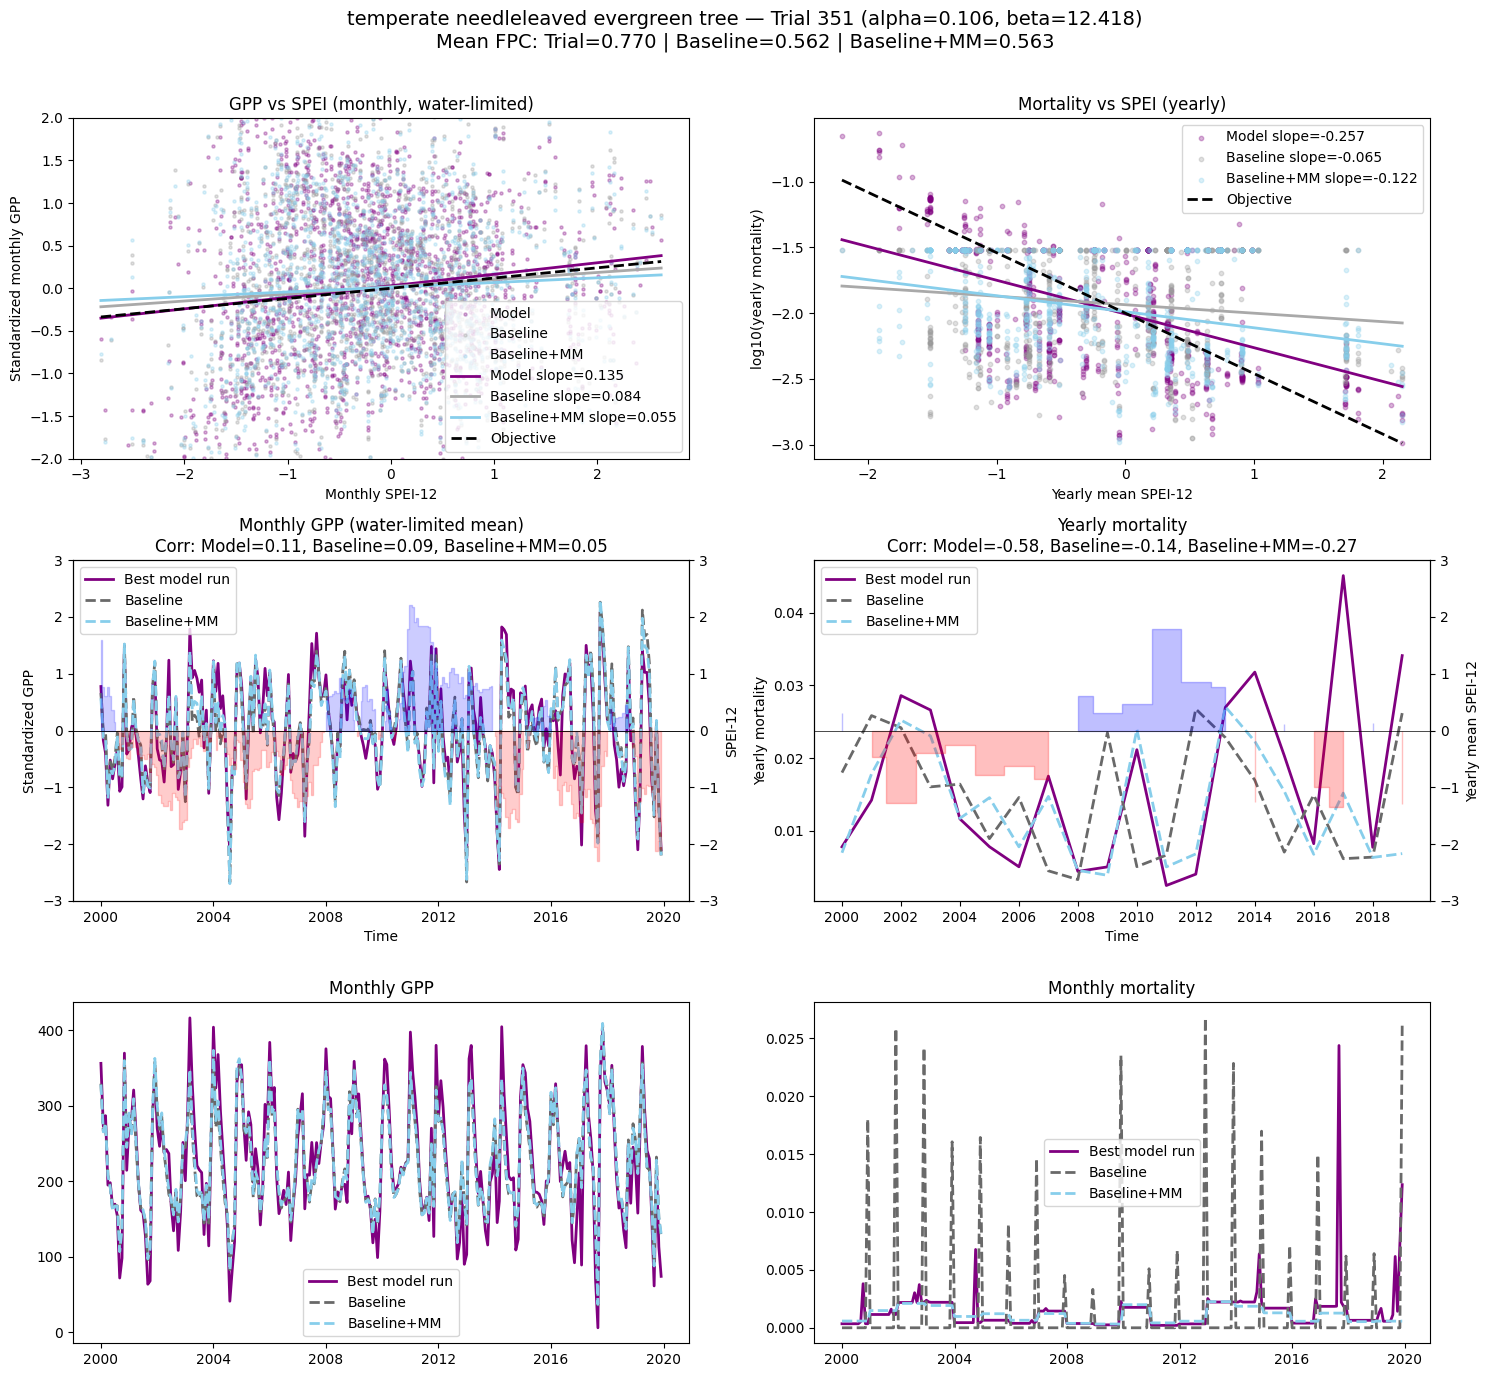


🔹 Processing temperate broadleaved evergreen tree
   Using 1/1 Pareto-optimal trial (1/1): 239
Using weighted knee-point trial: 239


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

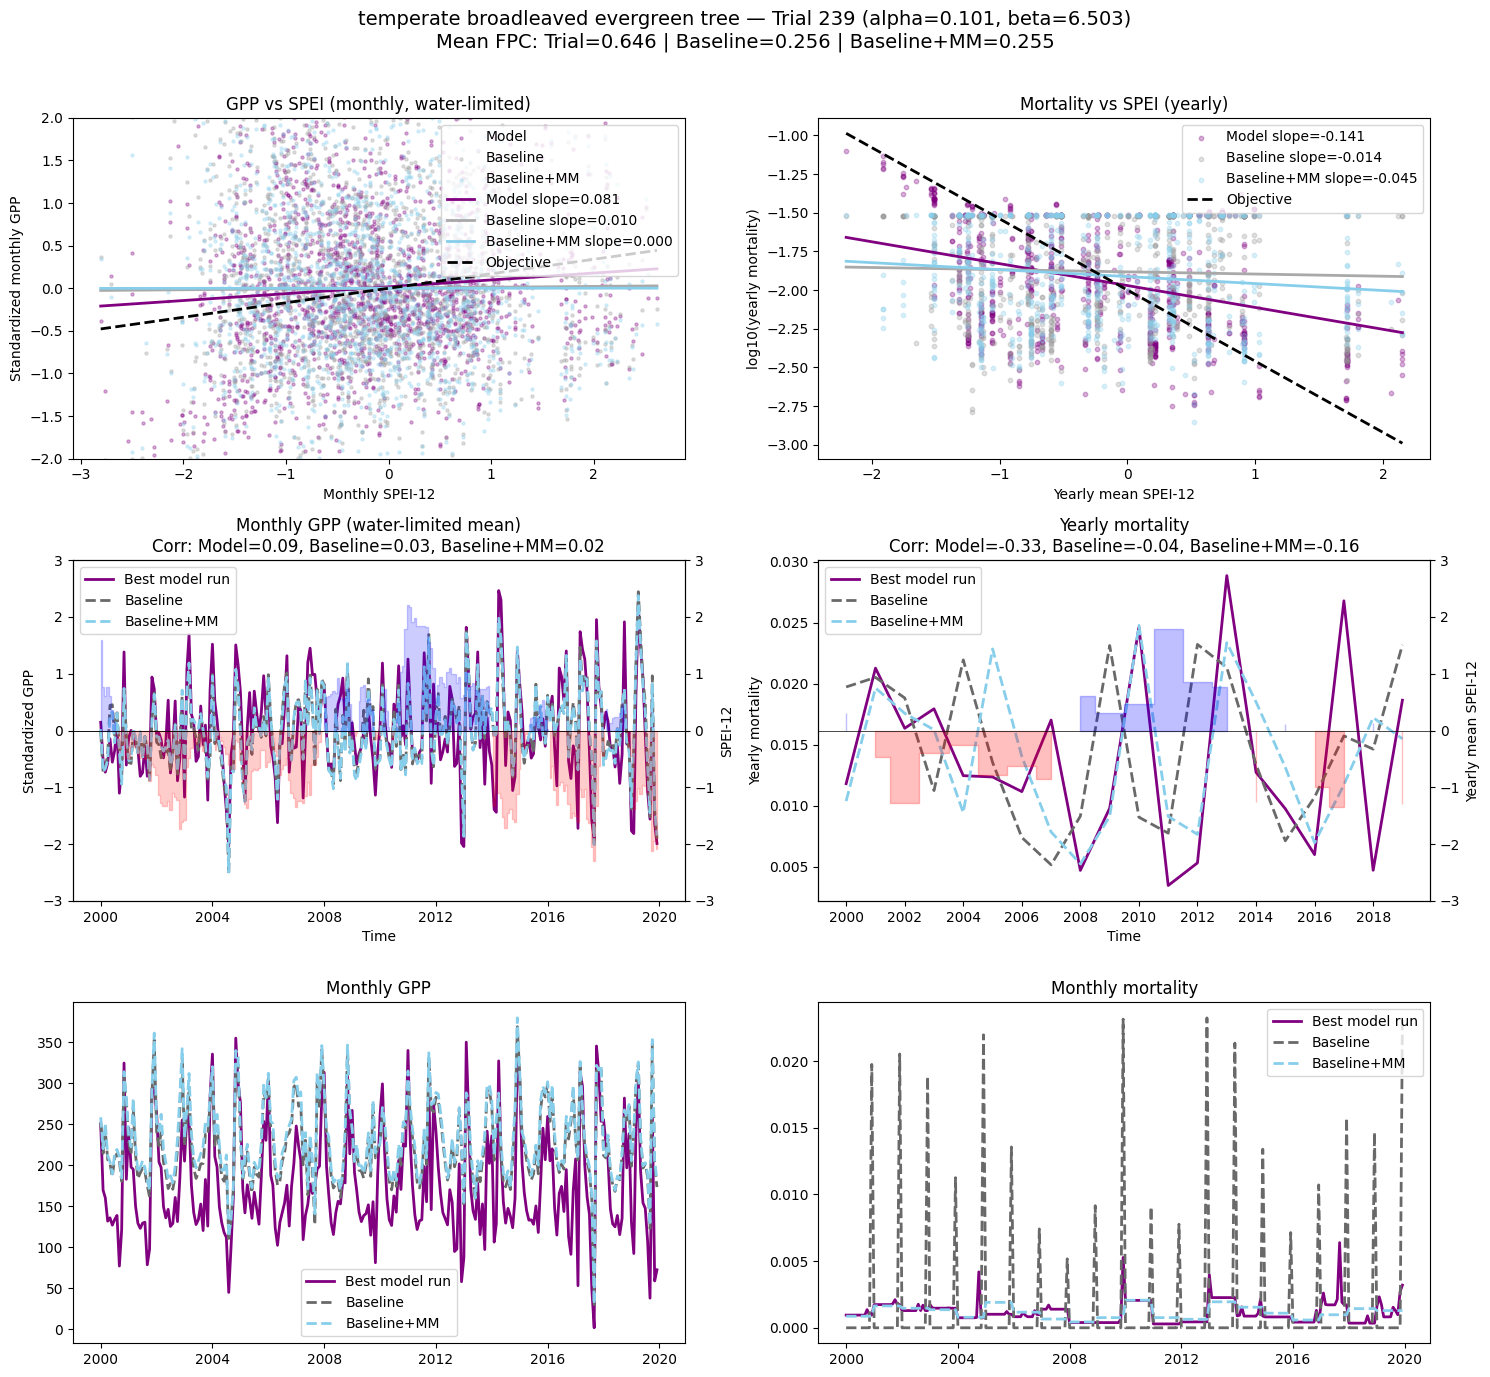


🔹 Processing temperate broadleaved summergreen tree
   Using 1/1 Pareto-optimal trial (9/9): 286
Using weighted knee-point trial: 286


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

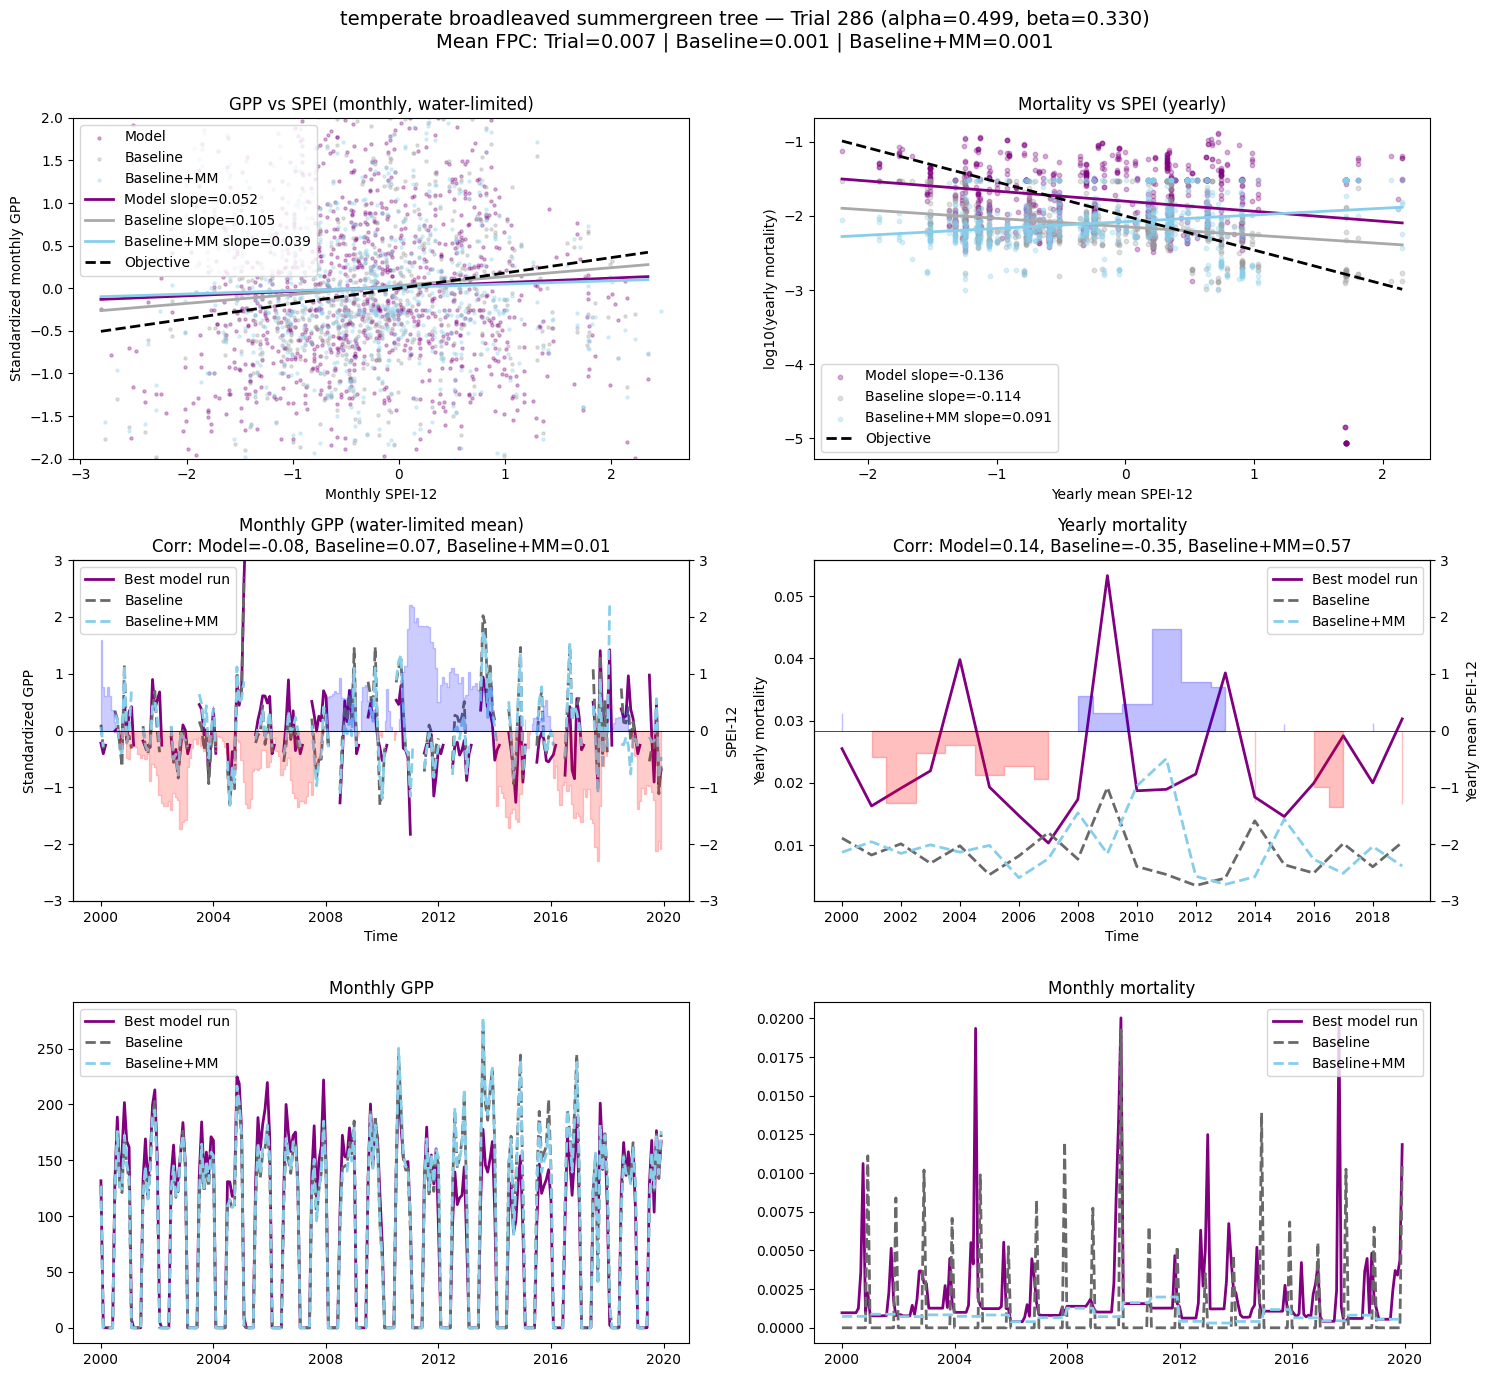


🔹 Processing boreal needleleaved evergreen tree
⏭️ No Pareto-optimal trials for boreal needleleaved evergreen tree

🔹 Processing boreal broadleaved summergreen tree
⏭️ No Pareto-optimal trials for boreal broadleaved summergreen tree

🔹 Processing boreal needleleaved summergreen tree
⏭️ No Pareto-optimal trials for boreal needleleaved summergreen tree


In [12]:
trial_dir_template = "/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location/temperate_needleleaved_evergreen_tree/run_{trial:04d}"

plot_spei_yearly_gpp_mort_all_pfts(df, trial_dir_template)

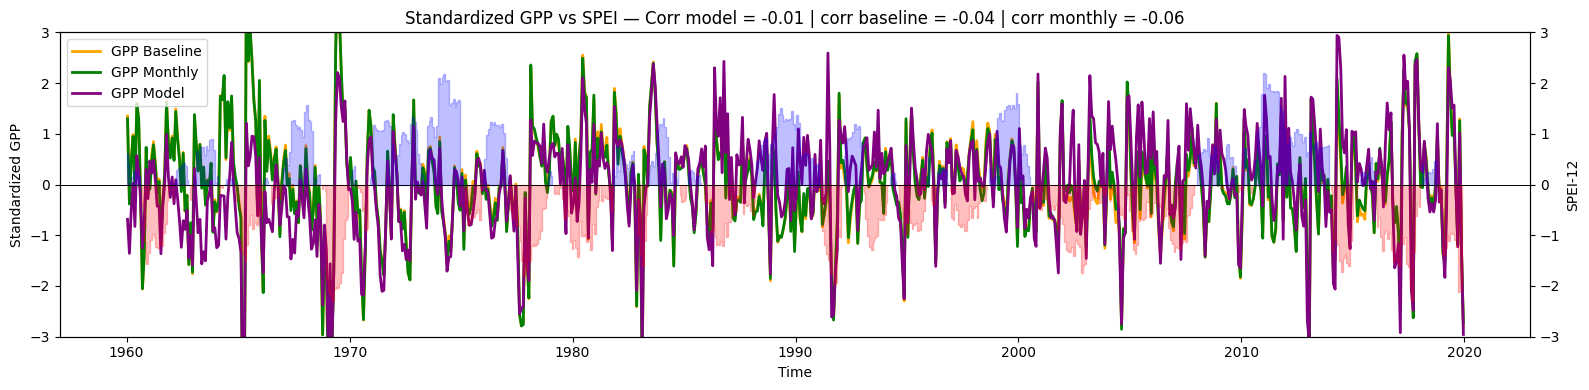

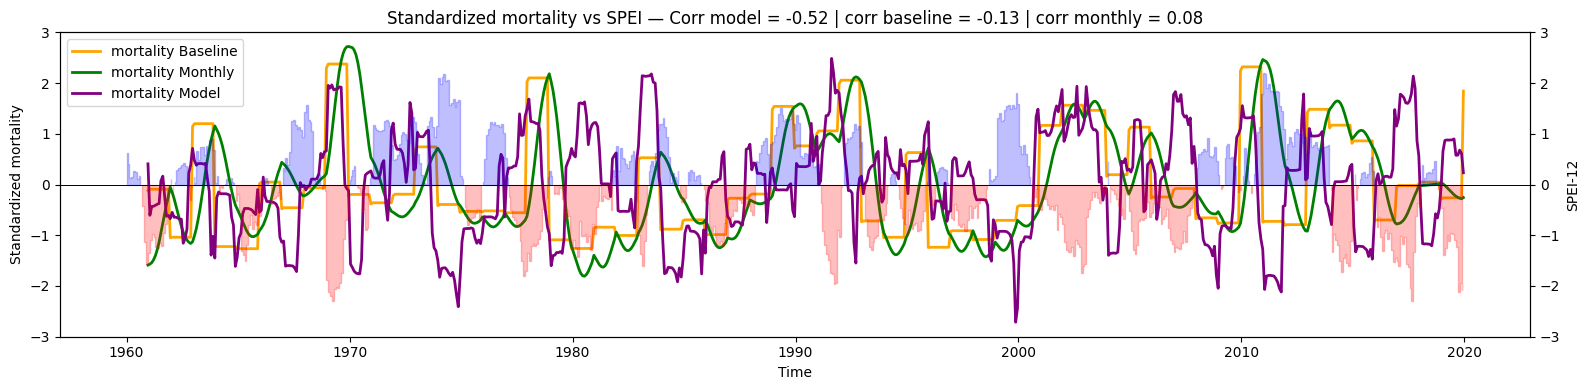

In [13]:
run_trial(351, obs_spei)
# run_trial(220, obs_spei)


Plotting alpha–beta contours for: tropical broadleaved evergreen tree


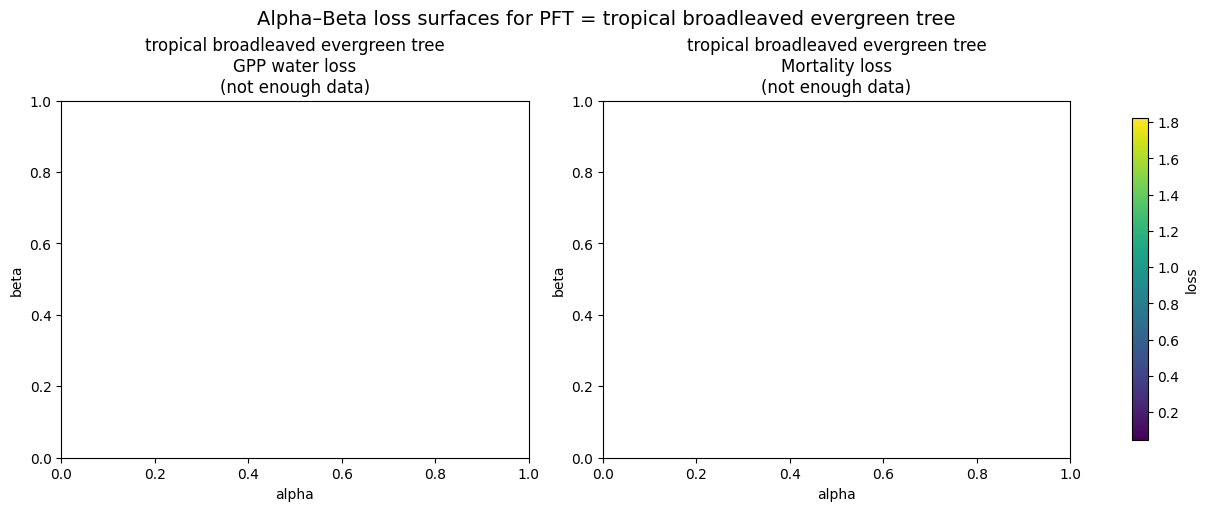

Plotting alpha–beta contours for: tropical broadleaved raingreen tree


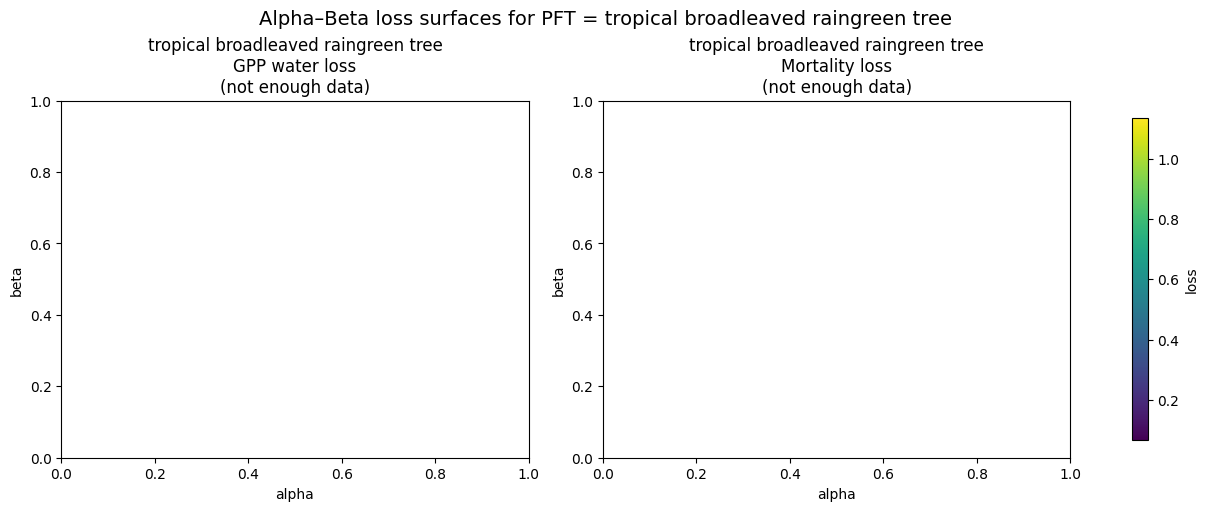

Plotting alpha–beta contours for: temperate needleleaved evergreen tree


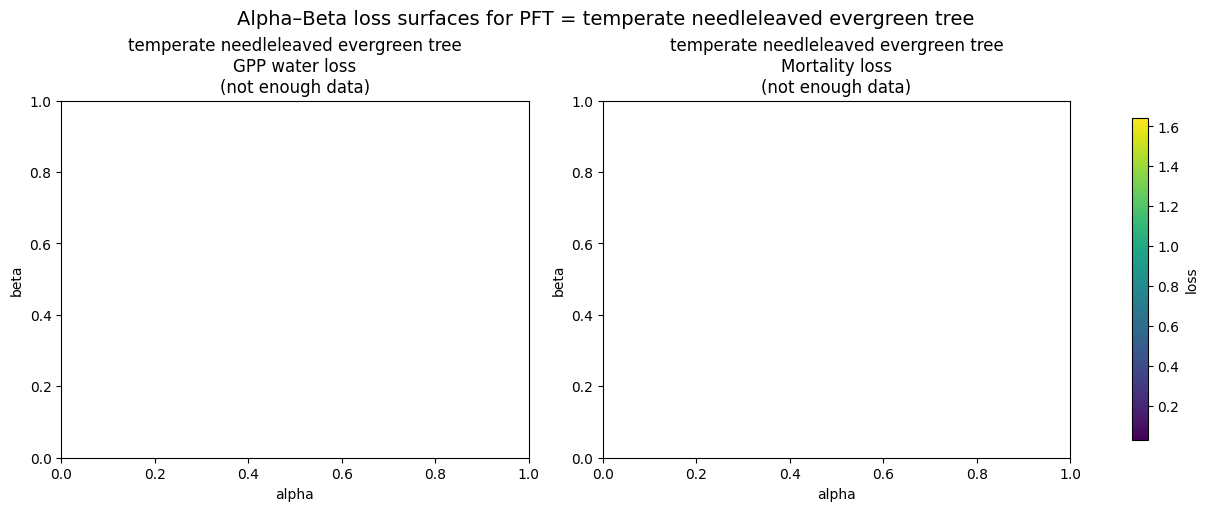

Plotting alpha–beta contours for: temperate broadleaved evergreen tree


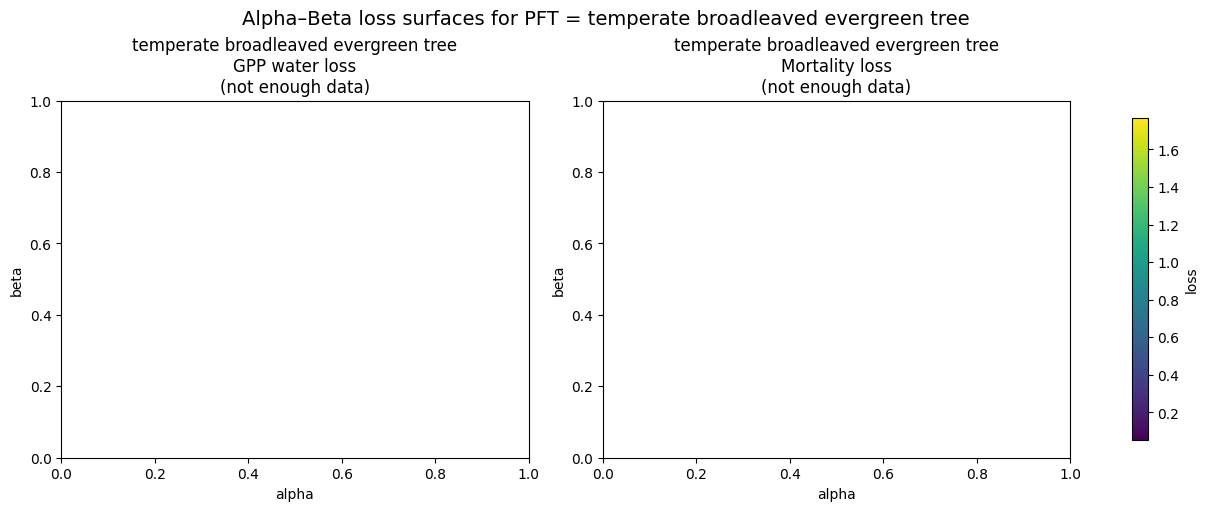

Plotting alpha–beta contours for: temperate broadleaved summergreen tree

⚠️ No valid data for PFT = temperate broadleaved summergreen tree
Plotting alpha–beta contours for: boreal needleleaved evergreen tree

⚠️ No valid data for PFT = boreal needleleaved evergreen tree
Plotting alpha–beta contours for: boreal broadleaved summergreen tree

⚠️ No valid data for PFT = boreal broadleaved summergreen tree
Plotting alpha–beta contours for: boreal needleleaved summergreen tree

⚠️ No valid data for PFT = boreal needleleaved summergreen tree


In [17]:
for pft in df["pft"].unique():
    print(f"Plotting alpha–beta contours for: {pft}")
    panel_alpha_beta_contours(df, pft, gpp_col="GPP_water")

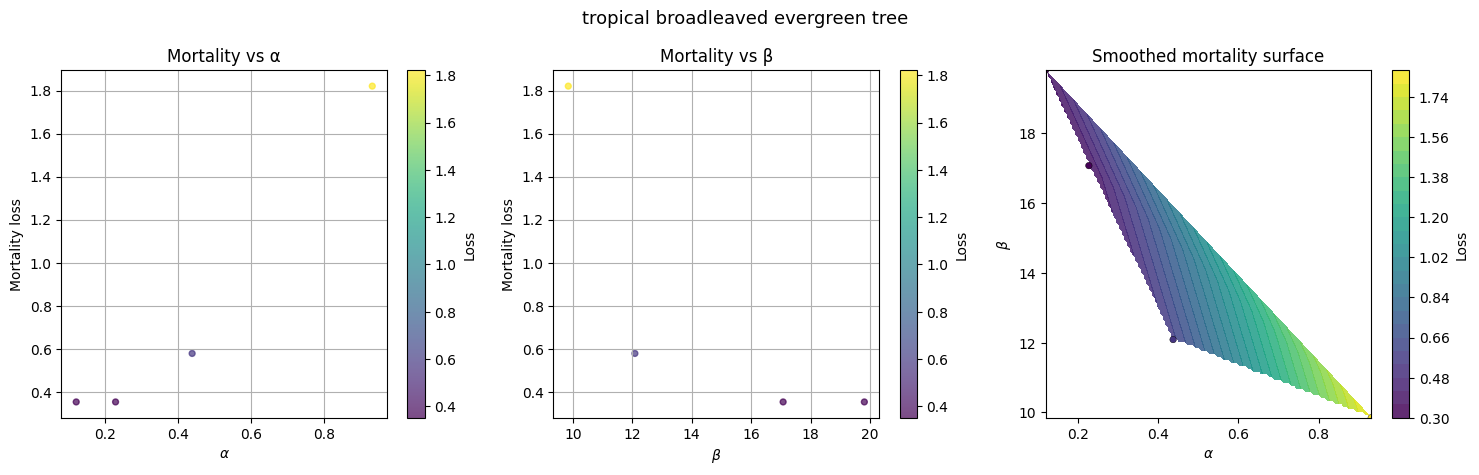

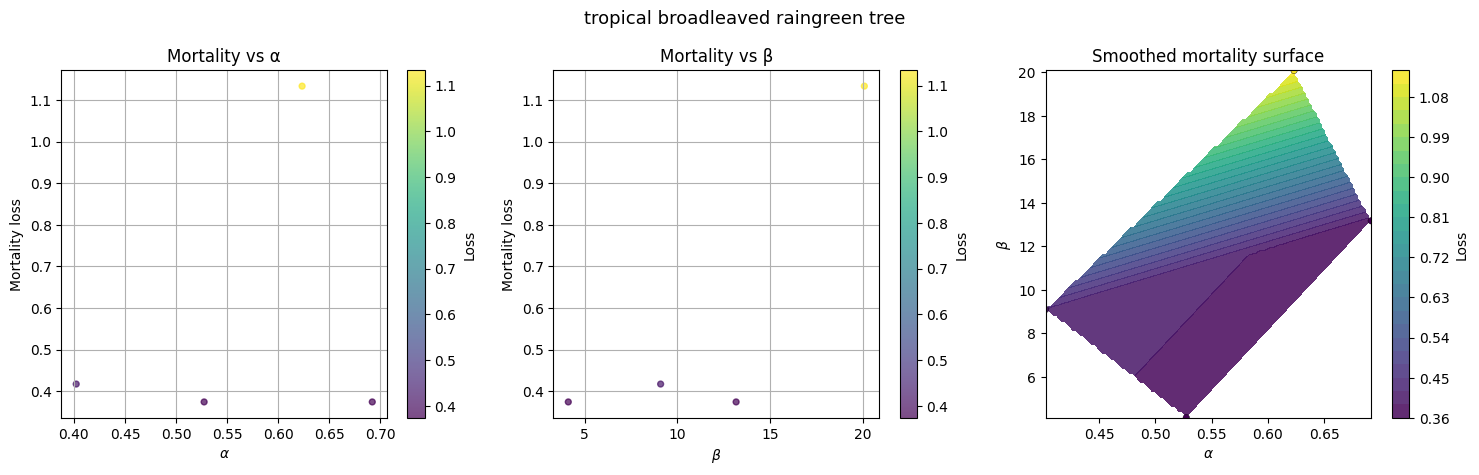

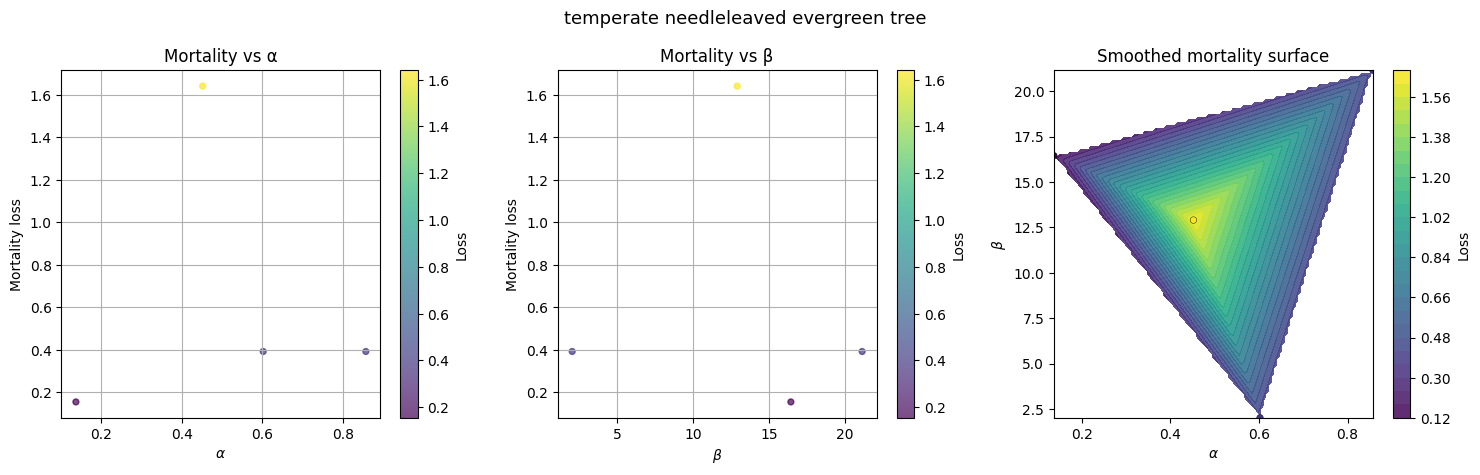

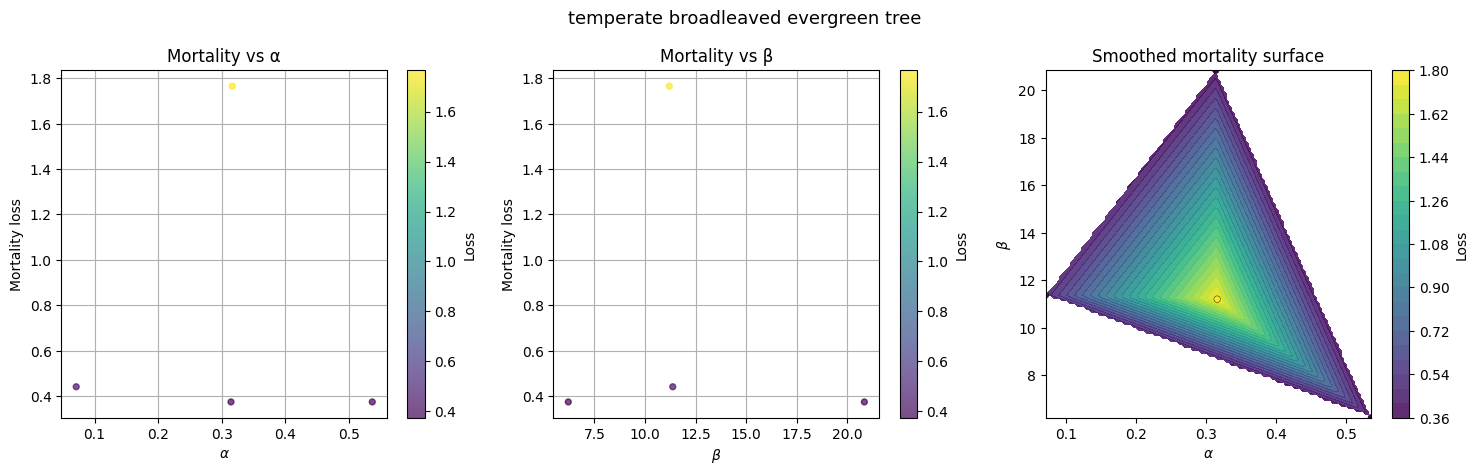

In [18]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

pft_list = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

for pft in pft_list:

    pft_key = pft.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    if alpha_col not in df.columns or beta_col not in df.columns:
        continue

    mort_df = df[
        (df["pft"] == pft) &
        (df["process"] == "MORT")
    ].copy()

    mort_df = mort_df.dropna(subset=[alpha_col, beta_col, "loss"])

    if mort_df.empty:
        continue

    x = mort_df[alpha_col].values
    y = mort_df[beta_col].values
    z = mort_df["loss"].values

    # ---------------------------------------
    # Interpolation grid
    # ---------------------------------------
    xi = np.linspace(x.min(), x.max(), 120)
    yi = np.linspace(y.min(), y.max(), 120)
    Xi, Yi = np.meshgrid(xi, yi)

    # ---------------------------------------
    # Interpolation grid (only if 2D)
    # ---------------------------------------
    do_surface = (np.unique(x).size >= 3) and (np.unique(y).size >= 3)

    if do_surface:
        xi = np.linspace(x.min(), x.max(), 120)
        yi = np.linspace(y.min(), y.max(), 120)
        Xi, Yi = np.meshgrid(xi, yi)

        Zi = griddata(
            (x, y), z,
            (Xi, Yi),
            method="linear"
        )
    else:
        Xi = Yi = Zi = None


    # ---------------------------------------
    # Plot
    # ---------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # ---- Mortality vs alpha
    sc0 = axes[0].scatter(
        x, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[0].set_xlabel(r"$\alpha$")
    axes[0].set_ylabel("Mortality loss")
    axes[0].set_title("Mortality vs α")
    axes[0].grid(True)
    fig.colorbar(sc0, ax=axes[0], label="Loss")

    # ---- Mortality vs beta
    sc1 = axes[1].scatter(
        y, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[1].set_xlabel(r"$\beta$")
    axes[1].set_ylabel("Mortality loss")
    axes[1].set_title("Mortality vs β")
    axes[1].grid(True)
    fig.colorbar(sc1, ax=axes[1], label="Loss")
    
    # ---- Alpha–beta surface + samples
    if Zi is not None and np.isfinite(Zi).any():
        cf = axes[2].contourf(
            Xi, Yi, Zi,
            levels=25,
            cmap="viridis",
            alpha=0.85
        )
    fig.colorbar(cf, ax=axes[2], label="Loss")

    sc2 = axes[2].scatter(
        x, y,
        c=z,
        s=22,
        edgecolor="k",
        linewidth=0.3
    )

    axes[2].set_xlabel(r"$\alpha$")
    axes[2].set_ylabel(r"$\beta$")
    axes[2].set_title(
        "Smoothed mortality surface" if Zi is not None else "Sampled parameter space"
    )
    

    fig.suptitle(pft, fontsize=13)
    plt.tight_layout()
    plt.show()


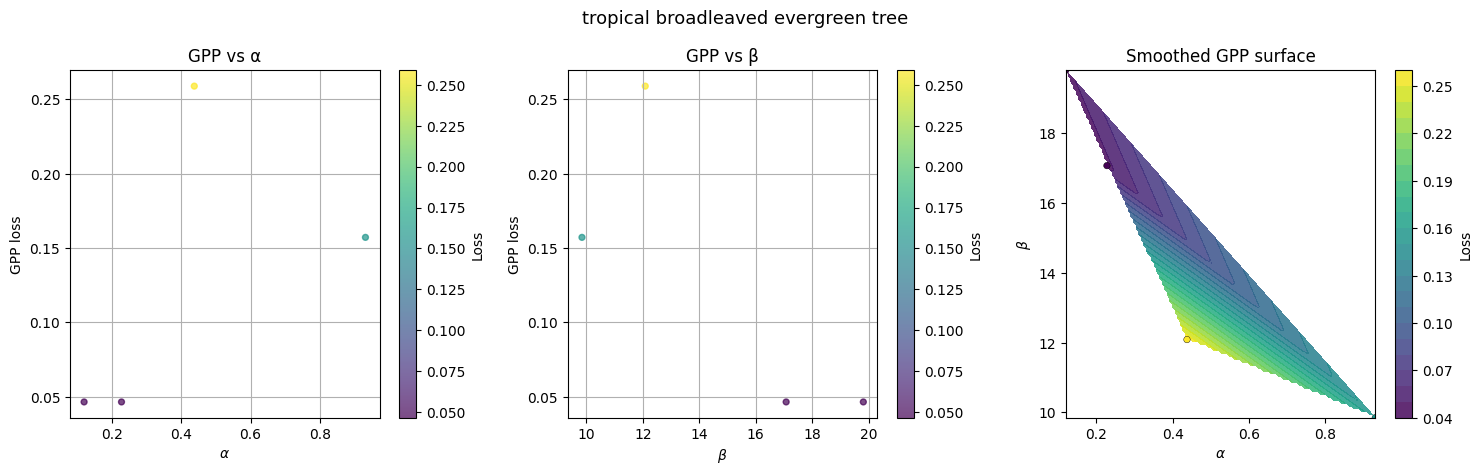

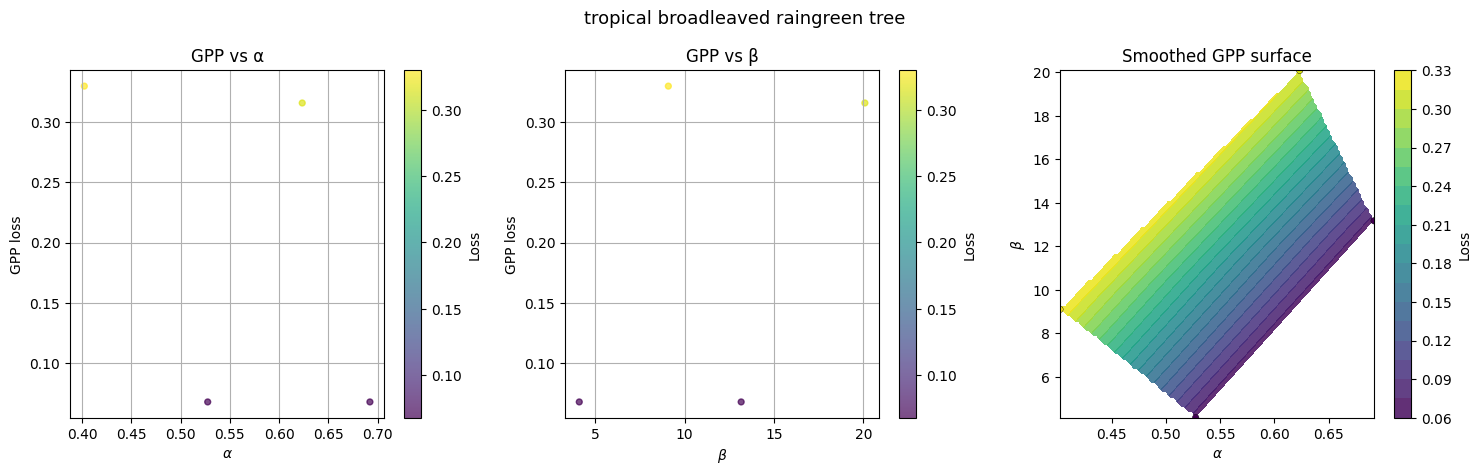

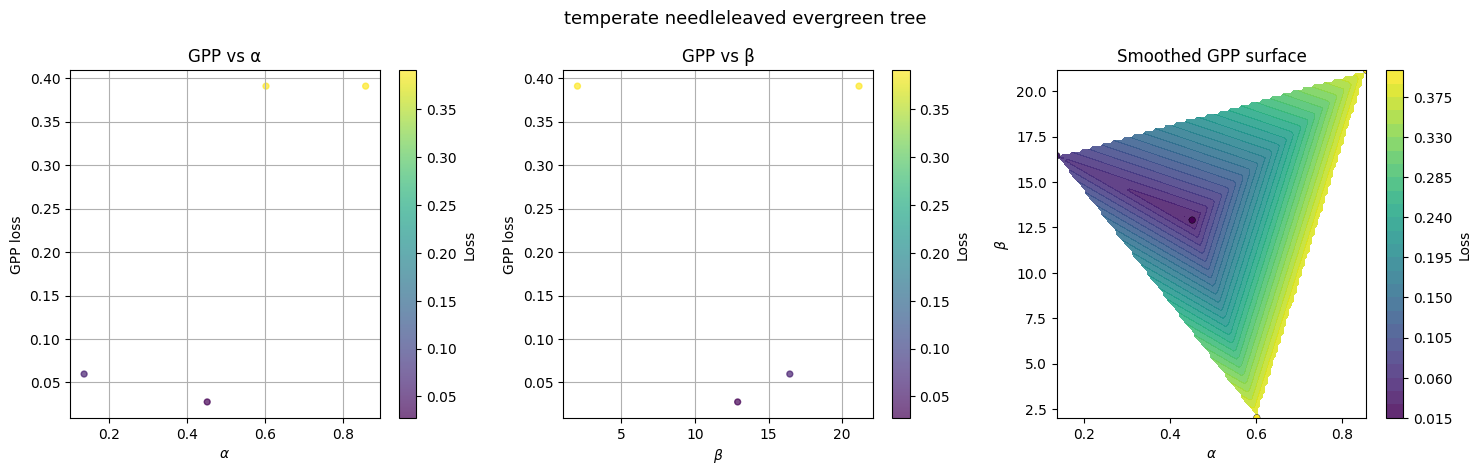

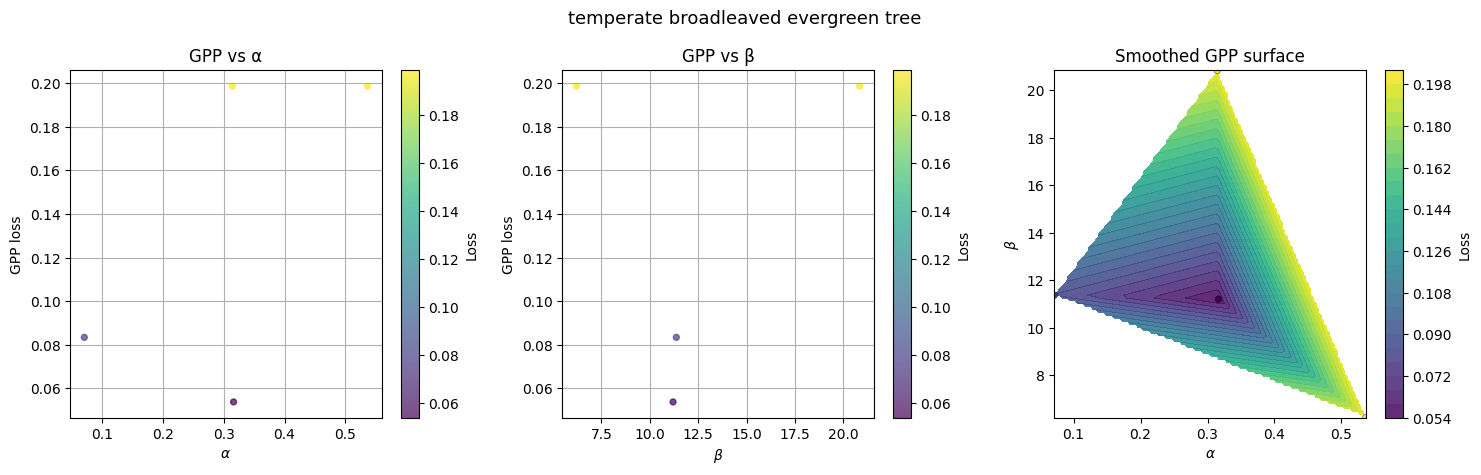

In [19]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

pft_list = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

for pft in pft_list:

    pft_key = pft.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    if alpha_col not in df.columns or beta_col not in df.columns:
        continue

    mort_df = df[
        (df["pft"] == pft) &
        (df["process"] == "GPP_water")
    ].copy()

    mort_df = mort_df.dropna(subset=[alpha_col, beta_col, "loss"])

    if mort_df.empty:
        continue

    x = mort_df[alpha_col].values
    y = mort_df[beta_col].values
    z = mort_df["loss"].values

    # ---------------------------------------
    # Interpolation grid
    # ---------------------------------------
    xi = np.linspace(x.min(), x.max(), 120)
    yi = np.linspace(y.min(), y.max(), 120)
    Xi, Yi = np.meshgrid(xi, yi)

    # ---------------------------------------
    # Interpolation grid (only if 2D)
    # ---------------------------------------
    do_surface = (np.unique(x).size >= 3) and (np.unique(y).size >= 3)

    if do_surface:
        xi = np.linspace(x.min(), x.max(), 120)
        yi = np.linspace(y.min(), y.max(), 120)
        Xi, Yi = np.meshgrid(xi, yi)

        Zi = griddata(
            (x, y), z,
            (Xi, Yi),
            method="linear"
        )
    else:
        Xi = Yi = Zi = None


    # ---------------------------------------
    # Plot
    # ---------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # ---- Mortality vs alpha
    sc0 = axes[0].scatter(
        x, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[0].set_xlabel(r"$\alpha$")
    axes[0].set_ylabel("GPP loss")
    axes[0].set_title("GPP vs α")
    axes[0].grid(True)
    fig.colorbar(sc0, ax=axes[0], label="Loss")

    # ---- Mortality vs beta
    sc1 = axes[1].scatter(
        y, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[1].set_xlabel(r"$\beta$")
    axes[1].set_ylabel("GPP loss")
    axes[1].set_title("GPP vs β")
    axes[1].grid(True)
    fig.colorbar(sc1, ax=axes[1], label="Loss")
    
    # ---- Alpha–beta surface + samples
    if Zi is not None and np.isfinite(Zi).any():
        cf = axes[2].contourf(
            Xi, Yi, Zi,
            levels=25,
            cmap="viridis",
            alpha=0.85
        )
    fig.colorbar(cf, ax=axes[2], label="Loss")

    sc2 = axes[2].scatter(
        x, y,
        c=z,
        s=22,
        edgecolor="k",
        linewidth=0.3
    )

    axes[2].set_xlabel(r"$\alpha$")
    axes[2].set_ylabel(r"$\beta$")
    axes[2].set_title(
        "Smoothed GPP surface" if Zi is not None else "Sampled parameter space"
    )
    

    fig.suptitle(pft, fontsize=13)
    plt.tight_layout()
    plt.show()
